# 1. Load data

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
from pathlib import Path
from datetime import datetime

def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data").is_dir() and (cand / "artifacts").is_dir():
            return cand
    raise FileNotFoundError("Could not find project root containing both ./data and ./artifacts")

ROOT = find_project_root()
DATA_ROOT = ROOT / "data"
ART_ROOT  = ROOT / "artifacts"

# Choose the application folder name under ./data

APP = "youtube"   
DIRECTION = "downlink"

APP = APP.strip().lower().replace(" ", "_").replace("-", "_")


APP_DIR = DATA_ROOT / APP
if not APP_DIR.is_dir():
    raise FileNotFoundError(f"APP_DIR not found: {APP_DIR}")

CSV_PATHS = sorted(APP_DIR.glob("*.csv"), key=lambda p: p.name)
if len(CSV_PATHS) == 0:
    raise FileNotFoundError(f"No CSV files found in: {APP_DIR}")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")


_direction_map = {
    "downlink": "downlink",
    "dl": "downlink",
    "down": "downlink",
    "d": "downlink",
    "uplink": "uplink",
    "ul": "uplink",
    "up": "uplink",
    "u": "uplink",
}

DIRECTION_RAW = str(DIRECTION)
DIRECTION = DIRECTION_RAW.strip().lower().replace(" ", "").replace("-", "")
DIRECTION = _direction_map.get(DIRECTION, DIRECTION)

if DIRECTION not in {"downlink", "uplink"}:
    raise ValueError(f"DIRECTION must be downlink/uplink (got: {DIRECTION_RAW!r})")



OUT_DIR = ART_ROOT / APP / DIRECTION / f"run_{RUN_ID}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def OUT(name: str) -> Path:
    return OUT_DIR / name

print("ROOT   :", ROOT)
print("APP_DIR:", APP_DIR)
print("Found CSVs:")
for p in CSV_PATHS:
    print("  -", p.name)
print("OUT_DIR:", OUT_DIR)
print("APP    :", APP)
print("DIR    :", DIRECTION)

ROOT   : /Users/ghinwaismail/Desktop/trafficgen-paper
APP_DIR: /Users/ghinwaismail/Desktop/trafficgen-paper/data/youtube
Found CSVs:
  - Youtube_A_1_Final.csv
  - Youtube_A_2_Final.csv
  - Youtube_A_3_Final.csv
  - Youtube_A_4_Final.csv
OUT_DIR: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755
APP    : youtube
DIR    : downlink


# per-app hyperparam

This hyperparam is not used in the generator, it will be considered only if the model failed to find the optimal params 

In [3]:
DEFAULT_HP = dict(
    # --- HDBSCAN ---
    min_cluster_size=60,
    min_samples=10,
    cluster_selection_method="eom",
    max_clusters=10,  # PAPER: Enforce bounded number of clusters (sanity constraint)

    # --- bootstrap/jitter in log-space ---
    jitter_std_log=0.05,

    # --- eps selection controls (for log clamps) ---
    eps_base_on=1e-4,
    eps_base_off=1e-4,
    eps_floor=1e-6,   # never go below this
)

APP_HP = {
    # App-specific values (tuned to keep clusters bounded as per Section V-A)
    "youtube":     dict(min_cluster_size=50, min_samples=25, jitter_std_log=0.05),
    "filimo":      dict(min_cluster_size=40, min_samples=25, jitter_std_log=0.04),
    "aparat":      dict(min_cluster_size=50, min_samples=5, jitter_std_log=0.06),
    "igap":        dict(min_cluster_size=15, min_samples=15, jitter_std_log=0.05),
    "telegram":    dict(min_cluster_size=20, min_samples=10, jitter_std_log=0.06),
}

def get_hp_for_app(app_name: str) -> dict:
    app_name = str(app_name).strip().lower().replace(" ", "_").replace("-", "_")
    hp = DEFAULT_HP.copy()
    hp.update(APP_HP.get(app_name, {}))
    return hp

hp = get_hp_for_app(APP)

min_cluster_size = int(hp["min_cluster_size"])
min_samples = hp["min_samples"]
cluster_selection_method = hp["cluster_selection_method"]
jitter_std_log = float(hp["jitter_std_log"])
max_clusters = int(hp["max_clusters"])  # NEW: Extract max clusters parameter

eps_base_on  = float(hp["eps_base_on"])
eps_base_off = float(hp["eps_base_off"])
eps_floor    = float(hp["eps_floor"])

print(f"[APP={APP}] HP: min_cluster_size={min_cluster_size}, min_samples={min_samples}, "
      f"method={cluster_selection_method}, jitter={jitter_std_log}, "
      f"max_clusters={max_clusters}, "  # NEW: Print max clusters
      f"eps_base_on={eps_base_on}, eps_base_off={eps_base_off}, eps_floor={eps_floor}")

[APP=youtube] HP: min_cluster_size=50, min_samples=25, method=eom, jitter=0.05, max_clusters=10, eps_base_on=0.0001, eps_base_off=0.0001, eps_floor=1e-06


# 2. Data Cleaning

In [4]:
DATA_DIR = APP_DIR
CSV_FILES = [p.name for p in CSV_PATHS]

def load_and_clean_one(csv_name: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    path = data_dir / csv_name
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path.resolve()}")

    df = pd.read_csv(path)


    if "Delta" in df.columns:
        df = df.drop(columns=["Delta"])

    # Make sure Time and Length are numeric
    for col in ["Time", "Length"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Remove any rows with invalid Time or Length
    df = df.dropna(subset=["Time", "Length"])

    # Sort by Time to fix non-monotonic capture ordering
    df = df.sort_values("Time").reset_index(drop=True)

    # Tag with source file name
    df["source_file"] = csv_name

    return df


In [5]:
# Load each CSV into a cleaned DataFrame
dfs = []
for fname in CSV_FILES:
    df_i = load_and_clean_one(fname, DATA_DIR)
    dfs.append(df_i)
    print(f"{fname}: {len(df_i):6d} packets, "
          f"time [{df_i['Time'].min():.3f}, {df_i['Time'].max():.3f}] s")

# Concatenate everything into a single DataFrame
data_all = pd.concat(dfs, ignore_index=True)

print("\nCombined dataframe shape:", data_all.shape)
data_all.head()


Youtube_A_1_Final.csv:  61952 packets, time [0.000, 370.657] s
Youtube_A_2_Final.csv:  60767 packets, time [0.000, 610.530] s
Youtube_A_3_Final.csv:  45957 packets, time [0.000, 450.319] s
Youtube_A_4_Final.csv:  50977 packets, time [0.000, 398.183] s

Combined dataframe shape: (219653, 8)


,No.,Time,Source,Destination,Protocol,Length,Info,source_file
0,1,0.000000,192.168.137.169,108.177.122.94,TCP,86,46438 > 443 [ACK] Seq=1 Ack=1 Win=3037 Len=0...,Youtube_A_1_Final.csv
1,2,0.000000,192.168.137.169,108.177.122.94,TCP,86,[TCP Dup ACK 1#1] 46438 > 443 [ACK] Seq=1 Ac...,Youtube_A_1_Final.csv
2,3,0.001640,108.177.122.94,192.168.137.169,SSLv2,1306,NaN,Youtube_A_1_Final.csv
3,4,0.001918,108.177.122.94,192.168.137.169,SSLv2,1306,[TCP Previous segment not captured],Youtube_A_1_Final.csv
4,5,0.002137,108.177.122.94,192.168.137.169,SSLv2,1306,NaN,Youtube_A_1_Final.csv


In [6]:
# Check that time is now monotonic in each file after sorting
for fname, df_i in zip(CSV_FILES, dfs):
    t = df_i["Time"].values
    is_monotonic = np.all(t[1:] >= t[:-1])
    duration = t.max() - t.min()
    print(f"{fname}: time_monotonic={is_monotonic}, duration_s={duration:.3f}")

print("\nColumns in combined dataframe:")
print(data_all.columns.tolist())


Youtube_A_1_Final.csv: time_monotonic=True, duration_s=370.657
Youtube_A_2_Final.csv: time_monotonic=True, duration_s=610.530
Youtube_A_3_Final.csv: time_monotonic=True, duration_s=450.319
Youtube_A_4_Final.csv: time_monotonic=True, duration_s=398.183

Columns in combined dataframe:
['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'source_file']


In [7]:
# Save a cleaned version to reuse later
OUT_PATH = OUT(f"{APP}_ALL_packets_clean.parquet")
data_all.to_parquet(OUT_PATH, index=False)
print(f"Saved cleaned packets to {OUT_PATH.resolve()}")


Saved cleaned packets to /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/youtube_ALL_packets_clean.parquet


In [8]:
OUT_CSV = OUT(f"{APP}_ALL_packets_clean.csv")

# index=False avoids an extra unnamed column
data_all.to_csv(OUT_CSV, index=False)

print(f"Saved cleaned packets to CSV at {OUT_CSV.resolve()}")


Saved cleaned packets to CSV at /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/youtube_ALL_packets_clean.csv


# 3. Media vs Signalling separation

In [9]:
def tag_traffic_role(df: pd.DataFrame, profile: str = "generic") -> pd.DataFrame:
    """
    Tag each packet as 'payload', 'setup', or 'unknown'.
    """
    df = df.copy()

    info = df["Info"].astype(str).str.lower()
    proto = df["Protocol"].astype(str).str.upper()

        # --- Profile-specific overrides for only this application
    if profile.lower() == "whatsapp":
        is_tcp = proto.eq("TCP")
        is_udp = proto.isin(["UDP", "STUN"])
        is_tls = proto.isin(["SSL", "SSLV2", "TLSV1", "TLSV1.2", "TLSV1.3"])
        is_dns = proto.eq("DNS")

        # TCP setup signals 
        tcp_synfinrst = info.str.contains(r"\b(?:syn|fin|rst)\b", regex=True)
        tcp_ack_only  = info.str.contains(r"\back\b", regex=True) & (~info.str.contains("psh")) & (df["Length"] <= 80)
        tcp_keepalive = info.str.contains(r"keep\s?alive")
        tcp_setup     = is_tcp & (tcp_synfinrst | tcp_ack_only | tcp_keepalive)

        # TLS: handshake vs application data
        tls_handshake = is_tls & info.str.contains(r"(client hello|server hello|certificate|new session ticket|hello retry|key share|change cipher spec)")
        tls_appdata   = is_tls & info.str.contains(r"(application data|continuation data|encrypted data)")

        # UDP: treat as payload by default; STUN control can be setup-ish
        stun_control  = proto.eq("STUN") & info.str.contains(r"(binding|allocate|stun)")
        udp_payload   = is_udp & ~stun_control

        setup_mask   = tcp_setup | tls_handshake | stun_control | is_dns
        payload_mask = udp_payload | (is_tcp & ~tcp_setup & ~tls_handshake) | tls_appdata

    else:
        is_quic = proto.eq("QUIC") | proto.eq("GQUIC")
        is_tcp  = proto.eq("TCP")
        is_tls  = proto.isin(["SSL", "SSLV2", "TLSV1", "TLSV1.2", "TLSV1.3"])
        is_dns  = proto.eq("DNS")

        quic_handshake = is_quic & info.str.contains("initial|handshake|client hello|server hello")
        quic_payload   = is_quic & (~quic_handshake)

        tcp_synfinrst  = info.str.contains(r"\b(?:syn|fin|rst)\b", regex=True)
        tcp_ack_only   = (info.str.contains(r"\back\b", regex=True)
                          & (~info.str.contains("psh")) & (df["Length"] <= 80))
        tcp_keepalive  = info.str.contains(r"keep\s?alive")
        tcp_setup      = is_tcp & (tcp_synfinrst | tcp_ack_only | tcp_keepalive)

        setup_mask   = quic_handshake | tcp_setup | is_tls | is_dns
        payload_mask = quic_payload | (is_tcp & ~tcp_setup)


    traffic_role = np.where(setup_mask, "setup",
                    np.where(payload_mask, "payload", "unknown"))

    df["traffic_role"] = traffic_role
    df["Plane"] = traffic_role   # keep to avoid breaking later cells
    return df


In [10]:
data_all = tag_traffic_role(data_all, profile=APP)

print("traffic_role counts:")
print(data_all["traffic_role"].value_counts())
print("\ntraffic_role per file:")
print(data_all.groupby(["source_file", "traffic_role"]).size())


traffic_role counts:
traffic_role
payload    216056
setup        3556
unknown        41
Name: count, dtype: int64

traffic_role per file:
source_file            traffic_role
Youtube_A_1_Final.csv  payload         60754
                       setup            1158
                       unknown            40
Youtube_A_2_Final.csv  payload         59900
                       setup             867
Youtube_A_3_Final.csv  payload         45251
                       setup             705
                       unknown             1
Youtube_A_4_Final.csv  payload         50151
                       setup             826
dtype: int64


In [11]:
media_all   = data_all[data_all["traffic_role"] == "payload"].copy()
signal_all  = data_all[data_all["traffic_role"] == "setup"].copy()
unknown_all = data_all[data_all["traffic_role"] == "unknown"].copy()

print("media rows   :", len(media_all))
print("signal rows  :", len(signal_all))
print("unknown rows :", len(unknown_all))

media rows   : 216056
signal rows  : 3556
unknown rows : 41


In [12]:
media_all.to_parquet(OUT(f"{APP}_ALL_media_packets.parquet"), index=False)
signal_all.to_parquet(OUT(f"{APP}_ALL_signal_packets.parquet"), index=False)


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import ipaddress

_CGNAT = ipaddress.ip_network("100.64.0.0/10")

def is_local_candidate(ip: str) -> bool:
    """Private/ULA + CGNAT. Excludes multicast/unspecified/etc."""
    try:
        addr = ipaddress.ip_address(ip)
        if addr.is_multicast or addr.is_unspecified or addr.is_loopback:
            return False
        if addr.version == 4 and addr in _CGNAT:
            return True
        return addr.is_private
    except ValueError:
        return False

def infer_local_ip_for_file(df_file: pd.DataFrame) -> str:
    """
    Pick the most frequent local candidate (private/ULA/CGNAT).
    Fallback: most frequent overall.
    """
    ips = pd.concat([df_file["Source"], df_file["Destination"]]).dropna().astype(str)
    counts = ips.value_counts()

    local_counts = [(ip, cnt) for ip, cnt in counts.items() if is_local_candidate(ip)]
    if local_counts:
        local_counts.sort(key=lambda t: t[1], reverse=True)
        return local_counts[0][0]

    return counts.index[0]


# Build mapping for media_all only (one local IP per source_file)
local_ip_map = {}
for fname, df_i in media_all.groupby("source_file"):
    local_ip = infer_local_ip_for_file(df_i)
    local_ip_map[fname] = local_ip

local_ip_map


{'Youtube_A_1_Final.csv': '192.168.137.169',
 'Youtube_A_2_Final.csv': '192.168.137.6',
 'Youtube_A_3_Final.csv': '192.168.137.6',
 'Youtube_A_4_Final.csv': '192.168.137.231'}

# 4. Direction separation

In [14]:
def compute_direction(row) -> str:
    local_ip = local_ip_map[row["source_file"]]
    src = str(row["Source"])
    dst = str(row["Destination"])

    if src == local_ip and dst != local_ip:
        return "uplink"
    elif dst == local_ip and src != local_ip:
        return "downlink"
    else:
        return "other"  # rare: remote-to-remote

media_all["Direction"] = media_all.apply(compute_direction, axis=1)

print(media_all["Direction"].value_counts())
print("\nBy file:")
print(media_all.groupby(["source_file", "Direction"]).size())


Direction
downlink    129059
uplink       86997
Name: count, dtype: int64

By file:
source_file            Direction
Youtube_A_1_Final.csv  downlink     35583
                       uplink       25171
Youtube_A_2_Final.csv  downlink     30807
                       uplink       29093
Youtube_A_3_Final.csv  downlink     31355
                       uplink       13896
Youtube_A_4_Final.csv  downlink     31314
                       uplink       18837
dtype: int64


In [15]:
import re
import numpy as np
import pandas as pd

def add_ports_if_available(df: pd.DataFrame) -> pd.DataFrame:
    """
    Try to create 'SrcPort' and 'DstPort' columns.
    Priority:
      1) existing columns if present (Src/Dst Port variants),
      2) parse from 'Info' as 'SPORT → DPORT' (typical Wireshark export),
      3) otherwise leave them NaN.
    """
    df = df.copy()

    # --- 1) Try to use existing columns 

    src_candidates = ["Src Port", "Source Port", "TCP Src Port", "UDP Src Port"]
    dst_candidates = ["Dst Port", "Destination Port", "TCP Dst Port", "UDP Dst Port"]

    src_col = next((c for c in src_candidates if c in df.columns), None)
    dst_col = next((c for c in dst_candidates if c in df.columns), None)

    if src_col is not None:
        df["SrcPort"] = pd.to_numeric(df[src_col], errors="coerce")
    else:
        df["SrcPort"] = np.nan

    if dst_col is not None:
        df["DstPort"] = pd.to_numeric(df[dst_col], errors="coerce")
    else:
        df["DstPort"] = np.nan

    # --- 2) If still missing, try to parse Info: '12345 → 443' 
    # Only for rows where we still have NaN
    if "Info" in df.columns:
        mask_need_src = df["SrcPort"].isna()
        mask_need_dst = df["DstPort"].isna()
        mask_need_any = mask_need_src | mask_need_dst

        if mask_need_any.any():
            pat = re.compile(r"(\d+)\s*(?:→|->|>)\s*(\d+)")
            info_series = df.loc[mask_need_any, "Info"].astype(str)

            src_values = []
            dst_values = []
            idx_values = []

            for idx, txt in info_series.items():
                m = pat.search(txt)
                if m:
                    s, d = m.groups()
                    src_values.append(int(s))
                    dst_values.append(int(d))
                    idx_values.append(idx)

            if idx_values:
                parsed = pd.DataFrame(
                    {
                        "index": idx_values,
                        "SrcPort_parsed": src_values,
                        "DstPort_parsed": dst_values,
                    }
                ).set_index("index")

                # fill only where still NaN
                df.loc[df["SrcPort"].isna(), "SrcPort"] = parsed["SrcPort_parsed"]
                df.loc[df["DstPort"].isna(), "DstPort"] = parsed["DstPort_parsed"]

    return df


In [16]:
def build_flow_id_with_ports(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a 'flow_id' string.

    - If SrcPort and DstPort are known (both not NaN), use:
        Source:SrcPort>Destination:DstPort|Protocol
    - Otherwise fall back to:
        Source>Destination|Protocol  
    """
    df = df.copy()

    # Ensure ports exist (even if NaN)
    if "SrcPort" not in df.columns or "DstPort" not in df.columns:
        df = add_ports_if_available(df)

    # ---- 3-tuple 
    
    base_id = (
        df["Source"].astype(str)
        + ">"
        + df["Destination"].astype(str)
        + "|"
        + df["Protocol"].astype(str)
    )

    # mask where we have valid ports
    has_ports = df["SrcPort"].notna() & df["DstPort"].notna()

    # build 5-tuple string for those rows
    flow_id_ports = (
        df["Source"].astype(str)
        + ":"
        + df["SrcPort"].astype("Int64").astype(str)  # Int64 allows NaN
        + ">"
        + df["Destination"].astype(str)
        + ":"
        + df["DstPort"].astype("Int64").astype(str)
        + "|"
        + df["Protocol"].astype(str)
    )

    # base 3-tuple; then override where ports exist
    df["flow_id"] = base_id
    df.loc[has_ports, "flow_id"] = flow_id_ports[has_ports]

    return df


In [17]:

media_all = build_flow_id_with_ports(media_all)

print("Number of distinct flows:", media_all["flow_id"].nunique())
media_all[["Time", "Source", "Destination", "Protocol", "Direction", "Plane", "flow_id"]].head()


Number of distinct flows: 398


,Time,Source,Destination,Protocol,Direction,Plane,flow_id
0,0.00000,192.168.137.169,108.177.122.94,TCP,uplink,payload,192.168.137.169:46438>108.177.122.94:443|TCP
1,0.00000,192.168.137.169,108.177.122.94,TCP,uplink,payload,192.168.137.169:46438>108.177.122.94:443|TCP
22,0.01139,192.168.137.169,108.177.122.94,TCP,uplink,payload,192.168.137.169:46438>108.177.122.94:443|TCP
23,0.01139,192.168.137.169,108.177.122.94,TCP,uplink,payload,192.168.137.169:46438>108.177.122.94:443|TCP
24,0.01139,192.168.137.169,108.177.122.94,TCP,uplink,payload,192.168.137.169:46438>108.177.122.94:443|TCP


In [18]:
print("Flows (old 3-tuple style):", 
      media_all.assign(
          old_flow_id=(
              media_all["Source"].astype(str)
              + ">"
              + media_all["Destination"].astype(str)
              + "|"
              + media_all["Protocol"].astype(str)
          )
      )["old_flow_id"].nunique()
)

print("Flows (new flow_id):", media_all["flow_id"].nunique())

print(
    media_all[["Source","Destination","Protocol","SrcPort","DstPort","flow_id"]]
    .drop_duplicates()
    .head(10)
)


Flows (old 3-tuple style): 354
Flows (new flow_id): 398
               Source      Destination Protocol  SrcPort  DstPort  \
0     192.168.137.169   108.177.122.94      TCP  46438.0    443.0   
88     108.177.122.94  192.168.137.169      TCP    443.0  46438.0   
164   192.168.137.169   108.177.122.94      TCP  46440.0    443.0   
2867  192.168.137.169  108.177.122.156      TCP  38504.0    443.0   
5860    173.194.29.87  192.168.137.169    GQUIC      NaN      NaN   
5866  192.168.137.169    173.194.29.87    GQUIC      NaN      NaN   
5868   173.194.29.107  192.168.137.169    GQUIC      NaN      NaN   
5872  192.168.137.169   173.194.29.107    GQUIC      NaN      NaN   
5874    173.194.29.91  192.168.137.169    GQUIC      NaN      NaN   
5878  192.168.137.169    173.194.29.91    GQUIC      NaN      NaN   

                                            flow_id  
0      192.168.137.169:46438>108.177.122.94:443|TCP  
88     108.177.122.94:443>192.168.137.169:46438|TCP  
164    192.168.137.169

In [19]:
media_dir = media_all[media_all["Direction"] == DIRECTION].copy()

print("Media packets (all directions):", len(media_all))
print("Media with choosed direction only          :", len(media_dir))
print("Fraction direction:", len(media_dir) / len(media_all))

# Save for later

media_dir.to_parquet(OUT(f"{APP}_media_{DIRECTION}_packets.parquet"), index=False)
media_dir.to_csv(OUT(f"{APP}_media_{DIRECTION}_packets.csv.gz"),
                 index=False, compression="gzip")

print("Media packets (all):", len(media_all))
print(f"Media packets ({DIRECTION}):", len(media_dir))

media_dir.head()


Media packets (all directions): 216056
Media with choosed direction only          : 129059
Fraction direction: 0.5973405043136965
Media packets (all): 216056
Media packets (downlink): 129059


,No.,Time,Source,Destination,Protocol,Length,Info,source_file,traffic_role,Plane,Direction,SrcPort,DstPort,flow_id
88,89,0.038316,108.177.122.94,192.168.137.169,TCP,1306,"443 > 46438 [PSH, ACK] Seq=790153 Ack=1 Win=...",Youtube_A_1_Final.csv,payload,payload,downlink,443.0,46438.0,108.177.122.94:443>192.168.137.169:46438|TCP
108,109,0.047237,108.177.122.94,192.168.137.169,TCP,1306,443 > 46438 [ACK] Seq=798833 Ack=1 Win=252 L...,Youtube_A_1_Final.csv,payload,payload,downlink,443.0,46438.0,108.177.122.94:443>192.168.137.169:46438|TCP
119,120,0.051813,108.177.122.94,192.168.137.169,TCP,1306,[TCP Previous segment not captured] 443 > 46...,Youtube_A_1_Final.csv,payload,payload,downlink,443.0,46438.0,108.177.122.94:443>192.168.137.169:46438|TCP
208,209,0.107490,108.177.122.94,192.168.137.169,TCP,1306,"[TCP Out-Of-Order] 443 > 46438 [PSH, ACK] Se...",Youtube_A_1_Final.csv,payload,payload,downlink,443.0,46438.0,108.177.122.94:443>192.168.137.169:46438|TCP
209,210,0.107756,108.177.122.94,192.168.137.169,TCP,1306,[TCP Out-Of-Order] 443 > 46438 [ACK] Seq=869...,Youtube_A_1_Final.csv,payload,payload,downlink,443.0,46438.0,108.177.122.94:443>192.168.137.169:46438|TCP


In [20]:
media_dir.to_csv(OUT(f"{APP}_media_{DIRECTION}_packets.csv"), index=False)

## sanity check

In [21]:
media_dir.info()
print("\nNaNs per column:")
print(media_dir.isna().sum())
# any NaNs or weird types in the key dataset?

<class 'pandas.core.frame.DataFrame'>
Index: 129059 entries, 88 to 219652
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   No.           129059 non-null  int64  
 1   Time          129059 non-null  float64
 2   Source        129059 non-null  object 
 3   Destination   129059 non-null  object 
 4   Protocol      129059 non-null  object 
 5   Length        129059 non-null  int64  
 6   Info          129059 non-null  object 
 7   source_file   129059 non-null  object 
 8   traffic_role  129059 non-null  object 
 9   Plane         129059 non-null  object 
 10  Direction     129059 non-null  object 
 11  SrcPort       2847 non-null    float64
 12  DstPort       2847 non-null    float64
 13  flow_id       129059 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 14.8+ MB

NaNs per column:
No.                  0
Time                 0
Source               0
Destination          0
Protocol        

In [22]:
print("traffic_role vs Protocol (media_all):")
print(pd.crosstab(media_all["traffic_role"], media_all["Protocol"]))

traffic_role vs Protocol (media_all):
Protocol       GQUIC   QUIC   TCP
traffic_role                     
payload       154072  56386  5598


In [23]:
# Direction really matches local IP?
rows_total = len(media_all)

bad_down = 0
bad_up = 0

for fname, local_ip in local_ip_map.items():
    sub = media_all[media_all["source_file"] == fname]

    #  downlink packets should have Destination == local_ip
    bad_down += ((sub["Direction"] == "downlink") & (sub["Destination"] != local_ip)).sum()

    # Uplink packets should have Source == local_ip
    bad_up += ((sub["Direction"] == "uplink") & (sub["Source"] != local_ip)).sum()

print("Total media packets:", rows_total)
print("Downlink packets with wrong dest:", bad_down)
print("Uplink packets with wrong src:", bad_up)
print("Fraction bad:", (bad_down + bad_up) / rows_total)


Total media packets: 216056
Downlink packets with wrong dest: 0
Uplink packets with wrong src: 0
Fraction bad: 0.0


In [24]:
# check Time monotonicity per (source_file, flow_id)
def is_time_monotonic(group: pd.DataFrame) -> bool:
    t = group["Time"].values
    return np.all(t[1:] >= t[:-1])

bad_flows = []

for (fname, fid), grp in media_dir.groupby(["source_file", "flow_id"]):
    if len(grp) >= 2 and not is_time_monotonic(grp):
        bad_flows.append((fname, fid, len(grp)))

print("Number of flows checked:", media_dir["flow_id"].nunique())
print("Flows with non-monotonic Time:", len(bad_flows))

# Show a few if there are any
bad_flows[:5]


Number of flows checked: 219
Flows with non-monotonic Time: 0


[]

In [25]:
# Basic stats by file and direction
summary = (
    media_dir
    .groupby(["source_file", "Direction"])
    .agg(
        packets=("Time", "size"),
        t_min=("Time", "min"),
        t_max=("Time", "max"),
        dur_s=("Time", lambda s: s.max() - s.min()),
        bytes_total=("Length", "sum"),
        len_mean=("Length", "mean")
    )
    .reset_index()
)

summary


,source_file,Direction,packets,t_min,t_max,dur_s,bytes_total,len_mean
0,Youtube_A_1_Final.csv,downlink,35583,0.038316,370.656825,370.618509,42918449,1206.150381
1,Youtube_A_2_Final.csv,downlink,30807,5.774919,610.309251,604.534332,35383893,1148.566657
2,Youtube_A_3_Final.csv,downlink,31355,0.261468,450.319063,450.057595,36374990,1160.101738
3,Youtube_A_4_Final.csv,downlink,31314,1.158906,398.182585,397.023679,37797011,1207.032350


In [26]:
# Inspect a couple of flows 
# Largest flows by packet count
flow_sizes = (
    media_dir.groupby(["source_file", "flow_id"])
    .size()
    .sort_values(ascending=False)
)

flow_sizes.head()


source_file            flow_id                             
Youtube_A_4_Final.csv  172.217.131.9>192.168.137.231|GQUIC     16156
Youtube_A_1_Final.csv  173.194.147.57>192.168.137.169|GQUIC     9246
Youtube_A_3_Final.csv  142.250.80.118>192.168.137.6|QUIC        5718
                       173.194.61.72>192.168.137.6|GQUIC        4591
Youtube_A_1_Final.csv  173.194.147.58>192.168.137.169|GQUIC     4564
dtype: int64

In [27]:
example_file, example_flow = flow_sizes.index[0]  # biggest flow
example = media_dir[(media_dir["source_file"] == example_file) &
                   (media_dir["flow_id"] == example_flow)].head(20)

example


,No.,Time,Source,Destination,Protocol,Length,Info,source_file,traffic_role,Plane,Direction,SrcPort,DstPort,flow_id
185807,17132,160.984508,172.217.131.9,192.168.137.231,GQUIC,1292,"Rejection, PKN: 1, CID: 1658159107834699757",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185814,17139,161.134129,172.217.131.9,192.168.137.231,GQUIC,1292,"Rejection, PKN: 2, CID: 1658159107834699757",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185815,17140,161.149490,172.217.131.9,192.168.137.231,GQUIC,75,"Payload (Encrypted), PKN: 3, CID: 165815910783...",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185817,17142,161.264493,172.217.131.9,192.168.137.231,GQUIC,1292,"Payload (Encrypted), PKN: 4",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185819,17144,161.269317,172.217.131.9,192.168.137.231,GQUIC,65,"Payload (Encrypted), PKN: 5",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185820,17145,161.272982,172.217.131.9,192.168.137.231,GQUIC,65,"Payload (Encrypted), PKN: 6",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185821,17146,161.312841,172.217.131.9,192.168.137.231,GQUIC,65,"Payload (Encrypted), PKN: 7",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185822,17147,161.321121,172.217.131.9,192.168.137.231,GQUIC,65,"Payload (Encrypted), PKN: 8",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185823,17148,161.321812,172.217.131.9,192.168.137.231,GQUIC,990,"Payload (Encrypted), PKN: 10",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC
185824,17149,161.322534,172.217.131.9,192.168.137.231,GQUIC,60,"Payload (Encrypted), PKN: 11",Youtube_A_4_Final.csv,payload,payload,downlink,NaN,NaN,172.217.131.9>192.168.137.231|GQUIC


# 5. ON/OFF burst segmentation

In [28]:
# 1) Compute all inter-packet times (IPTs) and inspect them

In [29]:
import numpy as np
import pandas as pd

# work on a copy and keep Time sorted within each flow
media_dir = media_dir.sort_values(["source_file", "flow_id", "Time"]).reset_index(drop=True)

ipt_list = []

for (fname, fid), grp in media_dir.groupby(["source_file", "flow_id"]):
    t = grp["Time"].values
    if len(t) < 2:
        continue
    gaps = np.diff(t)
    # Keep only positive gaps (just in case of any numerical weirdness)
    gaps = gaps[gaps > 0]
    if len(gaps):
        ipt_list.append(gaps)

if not ipt_list:
    raise ValueError("No inter-packet gaps found in media dataset!")

ipt_all = np.concatenate(ipt_list)

print("Total IPT samples:", len(ipt_all))
print("IPT (s) basic stats:")
print(" min  :", ipt_all.min())
print(" mean :", ipt_all.mean())
print(" max  :", ipt_all.max())

# Some useful percentiles
for q in [50, 90, 95, 97, 98, 99, 99.5, 99.9]:
    val = np.percentile(ipt_all, q)
    print(f" p{q:4.1f} :", val)


Total IPT samples: 128839
IPT (s) basic stats:
 min  : 8.599999998182284e-05
 mean : 0.1598707418871615
 max  : 354.13688
 p50.0 : 0.0007070000000055643
 p90.0 : 0.015259800000012536
 p95.0 : 0.057164100000005554
 p97.0 : 0.1445825800000125
 p98.0 : 0.25852827999998207
 p99.0 : 0.7097168200000015
 p99.5 : 4.678308119999932
 p99.9 : 25.818623138000092


In [30]:
# THETA SELECTION WITH ADAPTIVE CURVATURE

def choose_theta_from_ipt_adaptive(ipt_values: np.ndarray,
                                   percentiles: list = [90, 95, 97, 98],
                                   clip: tuple[float, float] = (0.02, 1.5)) -> float:
    """
    robust theta selection that looks for the 'elbow' in the IPT distribution
    """
    ipt = np.asarray(ipt_values, float)
    ipt = ipt[ipt > 0]
    if ipt.size == 0:
        print("Warning: No positive IPT values found, using clip minimum")
        return clip[0]       # return minimum
    
    log_ipt = np.log(ipt)
    n_points = len(log_ipt)
    
    # Use multiple percentile candidates and pick the one with highest curvature change
    best_theta = clip[0]
    max_curvature = -np.inf
    
    for p in percentiles:
        if p >= 98:     # Avoid using too high percentiles
            continue
            
        # Calculate theta at this percentile
        log_theta_val = np.percentile(log_ipt, p)
        theta_val = float(np.exp(log_theta_val))
        
        # Calculate local curvature around this point
        idx = int(p/100 * n_points)
        if idx > 5 and idx < n_points - 5:
            # Local window around the percentile point
            local_window = log_ipt[idx-2:idx+3]
            
            # Simple curvature approximation (second derivative)
            if len(local_window) == 5:
                curvature = abs(local_window[0] - 2*local_window[2] + local_window[4])
            else:
                curvature = 0
            
            if curvature > max_curvature and clip[0] <= theta_val <= clip[1]:
                max_curvature = curvature
                best_theta = theta_val
    
    # Fallback if no good elbow found - use 97th percentile
    if best_theta == clip[0]:
        log_theta_fallback = np.percentile(log_ipt, 97.0)
        best_theta = float(np.exp(log_theta_fallback))
        print(f"No clear elbow found. Using 97th percentile fallback.")
    
    # Final clipping to ensure it's within bounds
    best_theta = float(np.clip(best_theta, clip[0], clip[1]))
    
    print(f"Selected θ = {best_theta:.6f} s (based on curvature analysis)")
    return best_theta


theta = choose_theta_from_ipt_adaptive(ipt_all, percentiles=[90, 95, 97], clip=(0.02, 1.5))
theta

Selected θ = 0.057164 s (based on curvature analysis)


0.05716409990476323

In [31]:
# Segment each flow into bursts and build the summary table
from typing import List, Dict, Any

def segment_flow_to_bursts(flow_df: pd.DataFrame, theta: float) -> List[Dict[str, Any]]:
    """
    Given a single-flow DataFrame (one source_file, one flow_id, downlink media),
    segment it into ON bursts based on θ.

    Convention:
      - A burst is a maximal sequence of packets where consecutive gaps <= θ.
      - 'off_dur_s' is the OFF duration *before* this burst:
          * NaN for the first burst in the flow
          * the gap that triggered this burst for subsequent bursts
    """
    if len(flow_df) == 0:
        return []

    # Ensure sorted by time within this flow
    g = flow_df.sort_values("Time")
    t = g["Time"].values
    L = g["Length"].values

    bursts = []
    n = len(g)

    burst_start_idx = 0
    off_before_current = np.nan       # first burst has no prior OFF

    for i in range(1, n):
        gap = t[i] - t[i-1]
        if gap > theta:
                  # close current burst [burst_start_idx, i-1]
            on_start = t[burst_start_idx]
            on_end   = t[i-1]
            on_dur   = on_end - on_start
            pkts     = i - burst_start_idx
            bytes_   = L[burst_start_idx:i].sum()

            bursts.append({
                "source_file": g["source_file"].iloc[0],
                "flow_id":     g["flow_id"].iloc[0],
                "burst_id":    len(bursts),                 # 0-based within flow
                "on_dur_s":    float(on_dur),
                "off_dur_s":   float(off_before_current) if not np.isnan(off_before_current) else np.nan,
                "packets":     int(pkts),
                "bytes":       int(bytes_),
                "t_start_s":   float(on_start),
                "t_end_s":     float(on_end),
            })

            # start new burst at i, with OFF = this gap
            burst_start_idx = i
            off_before_current = gap

    # close last burst
    on_start = t[burst_start_idx]
    on_end   = t[-1]
    on_dur   = on_end - on_start
    pkts     = n - burst_start_idx
    bytes_   = L[burst_start_idx:].sum()

    bursts.append({
        "source_file": g["source_file"].iloc[0],
        "flow_id":     g["flow_id"].iloc[0],
        "burst_id":    len(bursts),
        "on_dur_s":    float(on_dur),
        "off_dur_s":   float(off_before_current) if not np.isnan(off_before_current) else np.nan,
        "packets":     int(pkts),
        "bytes":       int(bytes_),
        "t_start_s":   float(on_start),
        "t_end_s":     float(on_end),
    })

    return bursts


In [32]:
all_bursts: List[Dict[str, Any]] = []

# Group by (source_file, flow_id) for clarity
for (fname, fid), grp in media_dir.groupby(["source_file", "flow_id"]):
    b = segment_flow_to_bursts(grp, theta)
    all_bursts.extend(b)

bursts_df = pd.DataFrame(all_bursts)

# Unique flow instance ID: (source_file, flow_id)
bursts_df["flow_uid"] = (
    bursts_df["source_file"].astype(str)
    + "||"
    + bursts_df["flow_id"].astype(str)
)

print("Total bursts:", len(bursts_df))
bursts_df.head()


Total bursts: 6662


,source_file,flow_id,burst_id,on_dur_s,off_dur_s,packets,bytes,t_start_s,t_end_s,flow_uid
0,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,0,0.069122,NaN,14,15611,7.901198,7.970320,Youtube_A_1_Final.csv||108.177.122.119>192.168...
1,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,1,0.016337,0.503272,3,1504,8.473592,8.489929,Youtube_A_1_Final.csv||108.177.122.119>192.168...
2,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,2,0.054856,6.005242,15,17451,14.495171,14.550027,Youtube_A_1_Final.csv||108.177.122.119>192.168...
3,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,3,0.111286,0.790231,4,2722,15.340258,15.451544,Youtube_A_1_Final.csv||108.177.122.119>192.168...
4,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,4,0.000000,0.883101,1,71,16.334645,16.334645,Youtube_A_1_Final.csv||108.177.122.119>192.168...


 Quick sanity checks on the burst summary

we want
on_dur_s mostly > 0, with reasonable ranges (ms to a few seconds).

off_dur_s NaN for first bursts, positive for later ones; no negatives.

packets and bytes positive integers.


In [33]:
print(bursts_df.describe()[["on_dur_s", "off_dur_s", "packets", "bytes"]])

print("\nNumber of bursts per file:")
print(bursts_df["source_file"].value_counts())

print("\nAny non-positive durations?")
print("on_dur_s <= 0:", (bursts_df["on_dur_s"] <= 0).sum())
print("off_dur_s <  0:", (bursts_df["off_dur_s"] < 0).sum())


          on_dur_s    off_dur_s      packets         bytes
count  6662.000000  6442.000000  6662.000000  6.662000e+03
mean      0.060143     3.135193    19.372411  2.288717e+04
std       0.181777    15.500389    75.506416  9.652100e+04
min       0.000000     0.057174     1.000000  5.700000e+01
25%       0.000000     0.104248     1.000000  7.700000e+01
50%       0.001571     0.195791     2.000000  1.292000e+03
75%       0.045263     0.442258     6.000000  4.083000e+03
max       2.907513   354.136880  2125.000000  2.701858e+06

Number of bursts per file:
source_file
Youtube_A_2_Final.csv    2226
Youtube_A_3_Final.csv    2097
Youtube_A_1_Final.csv    1408
Youtube_A_4_Final.csv     931
Name: count, dtype: int64

Any non-positive durations?
on_dur_s <= 0: 2927
off_dur_s <  0: 0


In [34]:
# A. How many flows, and does it match NaN off_dur?
n_flows = media_dir.groupby(["source_file", "flow_id"]).ngroups
n_first_bursts = bursts_df["off_dur_s"].isna().sum()
print("Number of flows        :", n_flows)
print("Bursts with NaN off_dur:", n_first_bursts)


Number of flows        : 220
Bursts with NaN off_dur: 220


In [35]:
# B. Proportion of zero-duration bursts

zero_on = bursts_df[bursts_df["on_dur_s"] == 0]
print("Zero-duration bursts:", len(zero_on))
print("Fraction:", len(zero_on) / len(bursts_df))


Zero-duration bursts: 2927
Fraction: 0.4393575502851996


In [36]:
# Are zero-duration bursts really single-packet?
zero_on_stats = bursts_df[bursts_df["on_dur_s"] == 0]["packets"].value_counts().sort_index()
zero_on_stats.head(10)

packets
1    2927
Name: count, dtype: int64

## The zero-duration bursts

start with option 1 (ε-clamp for logs) and let clustering tell us if they form their own clear cluster.


Build safe log-features (so zeros don’t explode anything).

Run a first clustering and see whether zero-duration / 1-packet bursts form their own group.


In [37]:
import numpy as np
import pandas as pd


def choose_eps_from_positive(x: pd.Series, base: float = 1e-4, floor: float = 1e-6) -> float:
    x_pos = x[x > 0]
    if len(x_pos) == 0:
        return max(base, floor)
    eps = min(float(x_pos.min() / 10.0), base)
    return max(eps, floor)

eps_on  = choose_eps_from_positive(bursts_df["on_dur_s"], base=eps_base_on,  floor=eps_floor)
eps_off = choose_eps_from_positive(bursts_df["off_dur_s"].dropna(), base=eps_base_off, floor=eps_floor)

print("ε_on  =", eps_on)
print("ε_off =", eps_off)


ε_on  = 1.6599999997879423e-05
ε_off = 0.0001


# 6. Features

In [38]:

def add_enhanced_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Rate features (packets per second, bytes per second)
    df['packet_rate'] = np.where(df['on_dur_s'] > 0, df['packets'] / df['on_dur_s'], 0)
    df['byte_rate'] = np.where(df['on_dur_s'] > 0, df['bytes'] / df['on_dur_s'], 0)
    
    # Size statistics per burst
    df['bytes_per_packet'] = np.where(df['packets'] > 0, df['bytes'].astype(float) / df['packets'], 0)
    
    # OFF duration relative to ON duration ratio
    df['off_on_ratio'] = np.where((df['off_dur_s'].notna()) & (df['on_dur_s'] > 0), 
                                   df['off_dur_s'] / df['on_dur_s'], np.nan)
    
    # Log-transform the new features with proper clamping
    eps_rate = 1e-3     # For rates
    eps_bpp = 1e-2      # For bytes per packet
    
    df['log_packet_rate'] = np.log(np.clip(df['packet_rate'].values, eps_rate, None))
    df['log_byte_rate'] = np.log(np.clip(df['byte_rate'].values, eps_rate, None))
    df['log_bytes_per_packet'] = np.log(np.clip(df['bytes_per_packet'].values, eps_bpp, None))
    df['log_off_on_ratio'] = np.log(np.clip(df['off_on_ratio'].fillna(eps_base_off).values, eps_base_off, None))
    
    return df

# Apply enhanced features to bursts_df BEFORE building features
bursts_df = add_enhanced_features(bursts_df)

# Then update feature_cols to include new features
feature_cols = [
    "log_on", "log_off", "log_packets", "log_bytes",
    "log_packet_rate", "log_byte_rate", "log_bytes_per_packet", "log_off_on_ratio",
    "is_first", "is_zero_on",
]


In [39]:
# build the feature table with clamped logs

bursts_feat = bursts_df.copy()

# Flags
bursts_feat["is_zero_on"] = (bursts_feat["on_dur_s"] == 0.0).astype(int)

# flag first burst in each flow (off_dur_s is NaN there)
bursts_feat["is_first"] = bursts_feat["off_dur_s"].isna().astype(int)

# Clamp durations for logs
on_clamped = np.clip(bursts_feat["on_dur_s"].values, eps_on, None)

# For OFF: we already marked first bursts with is_first,
# so we can safely replace NaN by eps_off for the log.

off_raw = bursts_feat["off_dur_s"].fillna(eps_off).values
off_clamped = np.clip(off_raw, eps_off, None)

# Logs
bursts_feat["log_on"]      = np.log(on_clamped)
bursts_feat["log_off"]     = np.log(off_clamped)
bursts_feat["log_packets"] = np.log(bursts_feat["packets"].astype(float))
bursts_feat["log_bytes"]   = np.log(bursts_feat["bytes"].astype(float))

bursts_feat[[
    "on_dur_s", "off_dur_s", "packets", "bytes",
    "log_on", "log_off", "log_packets", "log_bytes",
    "is_zero_on", "is_first"
]].head()


,on_dur_s,off_dur_s,packets,bytes,log_on,log_off,log_packets,log_bytes,is_zero_on,is_first
0,0.069122,NaN,14,15611,-2.671882,-9.210340,2.639057,9.655731,0,1
1,0.016337,0.503272,3,1504,-4.114323,-0.686624,1.098612,7.315884,0,0
2,0.054856,6.005242,15,17451,-2.903044,1.792633,2.708050,9.767152,0,0
3,0.111286,0.790231,4,2722,-2.195652,-0.235430,1.386294,7.909122,0,0
4,0.000000,0.883101,1,71,-11.006108,-0.124316,0.000000,4.262680,1,0


## save the statistics for future use

In [40]:
# SAVE pre-split artifacts needed for stats

flows = (
    bursts_df[["flow_uid", "source_file", "flow_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
rng = np.random.default_rng(123)
n = len(flows)
perm = rng.permutation(n)

# the validation is used only as a test 

n_train = int(0.7 * n)
n_val   = int(0.3 * n)  

print("Saving to OUT_DIR:", OUT_DIR)

# --- Guards ---
if "bursts_df" not in globals():
    raise NameError("bursts_df is not defined yet. Run burst extraction/segmentation first.")
if "flows" not in globals():
    raise NameError("flows is not defined yet. Run flow reconstruction first.")
if "OUT" not in globals():
    raise NameError("OUT(...) helper is not defined. Run the cell that defines OUT_DIR/OUT first.")

# --- Save files -
bursts_path = OUT("bursts_df.parquet")
bursts_df.to_parquet(bursts_path, index=False)
print("Saved:", bursts_path)

flows_path = OUT("flows.parquet")
flows.to_parquet(flows_path, index=False)
print("Saved:", flows_path)

# --- Verify what's in this run directory ---
print("Parquets in OUT_DIR now:")
for p in sorted(OUT_DIR.glob("*.parquet")):
    print(" -", p.name)


Saving to OUT_DIR: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/bursts_df.parquet
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/flows.parquet
Parquets in OUT_DIR now:
 - bursts_df.parquet
 - flows.parquet
 - youtube_ALL_media_packets.parquet
 - youtube_ALL_packets_clean.parquet
 - youtube_ALL_signal_packets.parquet
 - youtube_media_downlink_packets.parquet


# 7. flow level splitting 70/30

In [41]:
# 1) Build flow table (one row per flow instance)

split = np.array(["test"] * n, dtype=object)
split[perm[:n_train]] = "train"
# All remaining flows go to test set (no validation)
split[perm[n_train:]] = "test"

flows["split"] = split


# 2) Attach split back to bursts_df using the unique flow_uid
bursts_df = bursts_df.merge(
    flows[["flow_uid", "split"]],
    on="flow_uid",
    how="left"
)

print(flows["split"].value_counts())
print(bursts_df["split"].value_counts())


split
train    154
test      66
Name: count, dtype: int64
split
train    4450
test     2212
Name: count, dtype: int64


# 8. HDBSCAN: density-based hierarchical clustering.

In [42]:
# HDBSCAN CLUSTERING WITH AUTO-TUNING

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import hdbscan
from hdbscan import prediction
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

def find_best_hdbscan_hyperparameters(X_train, param_grid, max_clusters=10):
    """
    Grid search for HDBSCAN hyperparameters using internal validation metrics.
    Returns best parameters and the fitted clusterer.
    """
    best_score = -np.inf
    best_params = None
    best_clusterer = None
    results = []        # Store all results for analysis
    
    print(f"Searching across {len(param_grid['min_cluster_size']) * len(param_grid['min_samples'])} parameter combinations...")
    
    for min_cs in param_grid['min_cluster_size']:
        for min_samp in param_grid['min_samples']:
            try:
                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cs,
                    min_samples=min_samp,
                    cluster_selection_method='eom',
                    prediction_data=True
                )
                labels = clusterer.fit_predict(X_train)
                
                # Only evaluate if we have meaningful clusters
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                n_noise = list(labels).count(-1)
                noise_ratio = n_noise / len(labels) if len(labels) > 0 else 1
                
                # Quality criteria
                has_enough_clusters = 2 <= n_clusters <= max_clusters
                has_reasonable_noise = noise_ratio < 0.15
                has_enough_points = len(labels) - n_noise > len(labels) * 0.5
                
                if has_enough_clusters and has_reasonable_noise and has_enough_points:
                    # Use only non-noise points for scoring
                    mask = labels != -1
                    if mask.sum() > len(labels) * 0.5:
                        score = calinski_harabasz_score(X_train[mask], labels[mask])
                        results.append({
                            'min_cluster_size': min_cs,
                            'min_samples': min_samp,
                            'n_clusters': n_clusters,
                            'noise_ratio': noise_ratio,
                            'score': score
                        })
                        
                        if score > best_score:
                            best_score = score
                            best_params = (min_cs, min_samp)
                            best_clusterer = clusterer
                            
            except Exception as e:
                # Skip invalid parameter combinations
                continue
    
    # Print all valid results for debugging
    if results:
        print("\n=== Parameter Search Results ===")
        results_df = pd.DataFrame(results).sort_values('score', ascending=False)
        display(results_df.head(10))
    
    return best_params, best_clusterer, results_df if 'results_df' in locals() else None

# --- Prepare Data for Clustering ---
print("=== Preparing clustering data ===")

# Features to use for clustering
feature_cols = [
    "log_on", "log_off", "log_packets", "log_bytes",
    "log_packet_rate", "log_byte_rate", "log_bytes_per_packet", "log_off_on_ratio",
    "is_first", "is_zero_on",
]

# Select training data
train_flow_uids = flows[flows["split"] == "train"]["flow_uid"]
train_mask = bursts_feat["flow_uid"].isin(train_flow_uids)

# Build feature matrix for training
X_train = bursts_feat.loc[train_mask, feature_cols].to_numpy()
print(f"Training data shape: {X_train.shape}")

# Fit scaler on training data only
scaler_all = StandardScaler()
X_train_std = scaler_all.fit_transform(X_train)

# Transform ALL data with the same scaler
X_all = bursts_feat[feature_cols].to_numpy()
X_all_std = scaler_all.transform(X_all)

print(f"All data shape: {X_all_std.shape}")

# --- Hyperparameter Search ---
print("\n=== Starting HDBSCAN Hyperparameter Search ===")

param_grid = {
    'min_cluster_size': [15, 20, 25, 30, 40, 50],
    'min_samples': [5, 10, 15, 20, 25]
}

# Execute search
best_params, best_clusterer, search_results = find_best_hdbscan_hyperparameters(
    X_train_std, param_grid, max_clusters=10
)

# --- Apply Best Parameters ---
if best_params:
    best_min_cluster_size, best_min_samples = best_params
    print(f"\n✓ Best parameters found: min_cluster_size={best_min_cluster_size}, min_samples={best_min_samples}")
    print(f"  Calinski-Harabasz Score: {search_results.iloc[0]['score']:.3f}")
    
    # Update global variables with best parameters
    min_cluster_size = best_min_cluster_size
    min_samples = best_min_samples

    clusterer_all = best_clusterer
else:
    print("\n✗ Parameter search failed, enforcing max_clusters=10")
    
    # Start with app-specific defaults
    current_min_cluster_size = min_cluster_size
    current_min_samples = min_samples
    
    # Iteratively adjust parameters until we have <= 10 clusters or hit limits
    max_iterations = 10
    iteration = 0
    
    while iteration < max_iterations:
        # Fit clusterer with current parameters
        clusterer_temp = hdbscan.HDBSCAN(
            min_cluster_size=current_min_cluster_size,
            min_samples=current_min_samples,
            cluster_selection_method=cluster_selection_method,
            prediction_data=True,
        )
        clusterer_temp.fit(X_train_std)
        
        # Predict on training data to check cluster count
        labels_temp, _ = prediction.approximate_predict(clusterer_temp, X_train_std)
        n_clusters = len(np.unique(labels_temp[labels_temp != -1]))
        
        print(f"  Iteration {iteration + 1}: min_cluster_size={current_min_cluster_size}, "
              f"min_samples={current_min_samples} → {n_clusters} clusters")
        
        if n_clusters <= 10:
            clusterer_all = clusterer_temp
            min_cluster_size = current_min_cluster_size
            min_samples = current_min_samples
            print(f"✓ Using parameters: min_cluster_size={min_cluster_size}, min_samples={min_samples}")
            break
        
        # Too many clusters - increase min_cluster_size to get fewer clusters
        current_min_cluster_size += 5  # Increase by 5 each iteration
        iteration += 1
    else:
        # If we hit max iterations, use the last clusterer anyway
        print("⚠ Max iterations reached, using last attempt")
        clusterer_all = clusterer_temp

# --- Assign Cluster Labels to All Data ---
print("\n=== Assigning cluster labels ===")
labels_all, strengths_all = prediction.approximate_predict(clusterer_all, X_all_std)
bursts_feat["cluster_hdb_all"] = labels_all
bursts_feat["cluster_strength"] = strengths_all

# Remove the temporary variable reference
if 'X_train_std' in globals() or 'x_train_std' in globals():
    # Clean up to avoid future confusion
    globals().pop('x_train_std', None)

print("\n=== Final Clustering Results ===")
unique_labels = np.unique(labels_all)
print(f"Unique labels: {unique_labels}")
print(f"Cluster counts:")
cluster_counts = pd.Series(labels_all).value_counts().sort_index()
for label, count in cluster_counts.items():
    print(f"  Label {label}: {count} bursts ({count/len(labels_all)*100:.1f}%)")
print(f"\nNoise fraction: {np.mean(labels_all == -1):.3f}")

# --- Add Cluster Quality Metrics ---
print("\n=== Cluster Quality Metrics ===")

# Calculate DBCV score
try:
    dbcv_score = hdbscan.validity.validity_index(X_all_std, labels_all)
    print(f"DBCV Score: {dbcv_score:.3f}")
except:
    print("Could not calculate DBCV score")

# Calculate per-cluster silhouette scores (excluding noise)
from sklearn.metrics import silhouette_samples
mask_non_noise = labels_all != -1
if mask_non_noise.sum() > 0:
    silhouette_vals = silhouette_samples(X_all_std[mask_non_noise], labels_all[mask_non_noise])
    bursts_feat.loc[mask_non_noise, 'silhouette'] = silhouette_vals
    
    print("\nPer-cluster silhouette scores:")
    for label in unique_labels:
        if label != -1:
            mask_label = (bursts_feat["cluster_hdb_all"] == label) & (bursts_feat.index < len(silhouette_vals))
            if mask_label.any():
                sil_score = bursts_feat.loc[mask_label, 'silhouette'].mean()
                print(f"  Cluster {label}: {sil_score:.3f}")

print("\nClustering complete!")

=== Preparing clustering data ===
Training data shape: (4450, 10)
All data shape: (6662, 10)

=== Starting HDBSCAN Hyperparameter Search ===
Searching across 30 parameter combinations...

=== Parameter Search Results ===


,min_cluster_size,min_samples,n_clusters,noise_ratio,score
22,50,25,5,0.014607,3514.862837
21,50,20,5,0.015955,3505.930668
20,50,15,6,0.047416,2723.966242
15,40,10,7,0.078876,2119.944748
19,50,10,7,0.078876,2119.944748
16,40,15,7,0.082247,2098.324522
18,40,25,7,0.085169,2082.302666
17,40,20,7,0.088989,2063.735243
0,15,10,8,0.037978,1998.634057
7,25,10,8,0.037978,1998.634057



✓ Best parameters found: min_cluster_size=50, min_samples=25
  Calinski-Harabasz Score: 3514.863

=== Assigning cluster labels ===

=== Final Clustering Results ===
Unique labels: [-1  0  1  2  3  4]
Cluster counts:
  Label -1: 92 bursts (1.4%)
  Label 0: 3632 bursts (54.5%)
  Label 1: 102 bursts (1.5%)
  Label 2: 117 bursts (1.8%)
  Label 3: 1975 bursts (29.6%)
  Label 4: 744 bursts (11.2%)

Noise fraction: 0.014

=== Cluster Quality Metrics ===
DBCV Score: 0.441

Per-cluster silhouette scores:
  Cluster 0: 0.492
  Cluster 1: 0.776
  Cluster 2: 0.892
  Cluster 3: 0.741
  Cluster 4: 0.873

Clustering complete!


In [43]:
import numpy as np
import pandas as pd

def show(name, x, max_items=15):
    """Print variable name + a readable preview of its value."""
    print(f"\n=== {name} ===")
    if isinstance(x, pd.Series):
        print(x.to_string())
    elif isinstance(x, pd.DataFrame):
        print(x.head(max_items).to_string())
        if len(x) > max_items:
            print(f"... ({len(x)} rows total)")
    elif isinstance(x, np.ndarray):
        flat = x.ravel()
        n = min(len(flat), max_items)
        print(f"shape={x.shape}, dtype={x.dtype}")
        print(flat[:n])
        if len(flat) > n:
            print(f"... ({len(flat)} elements total)")
    else:
        print(x)


In [44]:
show("min_cluster_size", min_cluster_size)
show("min_samples", min_samples)
show("cluster_selection_method", cluster_selection_method)
show("jitter_std_log", jitter_std_log)



=== min_cluster_size ===
50

=== min_samples ===
25

=== cluster_selection_method ===
eom

=== jitter_std_log ===
0.05


FIG_DIR set to: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs
TABLE_DIR set to: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables
=== ENHANCED CLUSTER DIAGNOSTICS ===

Creating core_all dataset...
Core dataset size: 6570 bursts
1. CLUSTER DISTRIBUTION:
   Cluster 0: 3,632 bursts (55.3%)
   Cluster 1: 102 bursts (1.6%)
   Cluster 2: 117 bursts (1.8%)
   Cluster 3: 1,975 bursts (30.1%)
   Cluster 4: 744 bursts (11.3%)

2. CLUSTER QUALITY METRICS:
   Noise fraction: 0.000
   DBCV Score: 0.337
   Calinski-Harabasz: 17379.920
   Davies-Bouldin: 0.385

3. PER-CLUSTER SILHOUETTE SCORES:
                     mean       std  count
cluster_hdb_all                           
0                0.547765  0.077070   3632
1                0.780651  0.054039    102
2                0.901688  0.077803    117
3                0.682820  0.160316   1975
4                0.836409  0.066955    744


log_on                      log_off                      \
                   mean  median    std count    mean median    std count   
cluster_hdb_all                                                            
0                -3.526  -3.252  1.854  3632  -1.028 -1.755  1.845  3632   
1                -5.507  -5.702  1.695   102  -9.210 -9.210  0.000   102   
2               -11.006 -11.006  0.000   117  -9.210 -9.210  0.000   117   
3               -11.006 -11.006  0.000  1975  -1.311 -1.384  1.161  1975   
4               -11.006 -11.006  0.000   744  -1.783 -1.904  0.593   744   

                log_packets         ... log_off_on_ratio       is_first  \
                       mean median  ...              std count     mean   
cluster_hdb_all                     ...                                   
0                     2.135  1.609  ...            2.882  3632      0.0   
1                     1.303  1.099  ...            0.000   102      1.0   
2                     0.000  0.000  ...            0.000   117      1.0   
3                     0.000  0.000  ...            0.000  1975      0.0   
4                     0.000  0.000  ...            0.000   744      0.0   

                                  is_zero_on                    
                median  std count       mean median  std count  
cluster_hdb_all                                                 
0                  0.0  0.0  3632        0.0    0.0  0.0  3632  
1                  1.0  0.0   102        0.0    0.0  0.0   102  
2                  1.0  0.0   117        1.0    1.0  0.0   117  
3                  0.0  0.0  1975        1.0    1.0  0.0  1975  
4                  0.0  0.0   744        1.0    1.0  0.0   744  

[5 rows x 40 columns]

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/cluster_feature_stats_youtube_downlink.csv

5. VISUALIZING CLUSTERS IN 2D...
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_pca_projection_youtube_downlink.png
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_pca_projection_youtube_downlink.pdf


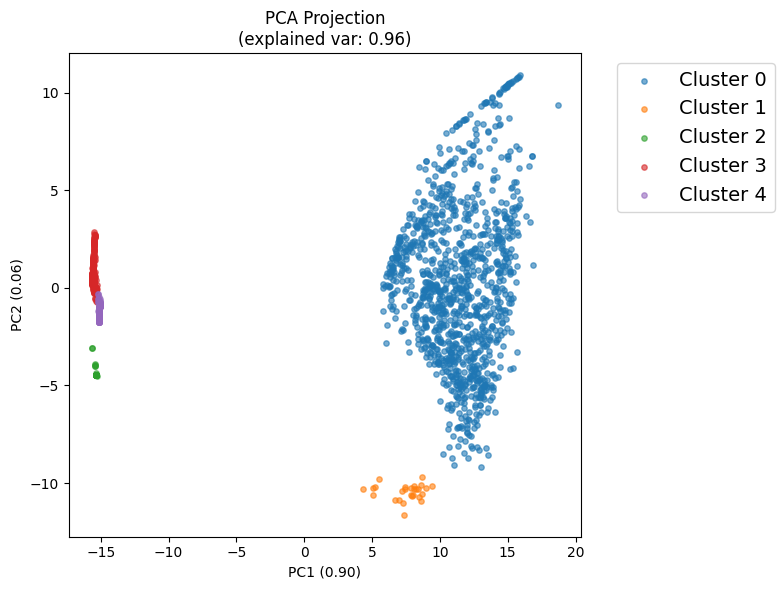

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_tsne_projection_youtube_downlink.png
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_tsne_projection_youtube_downlink.pdf


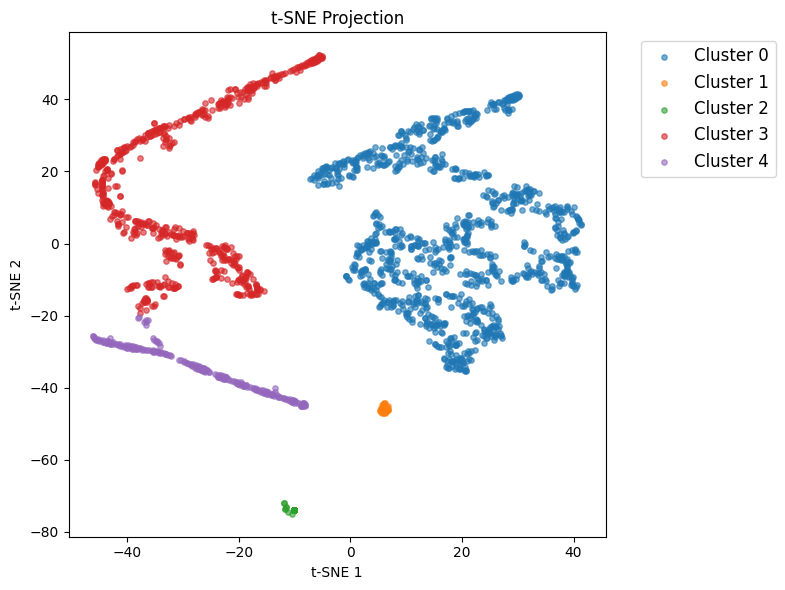

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/cluster_counts_youtube_downlink.csv
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/cluster_quality_summary_youtube_downlink.csv
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/silhouette_stats_youtube_downlink.csv

=== DIAGNOSTICS COMPLETE ===


In [45]:
# CLUSTER DIAGNOSTICS & VISUALIZATION


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# === ENSURE OUTPUT DIRECTORIES EXIST ===
if 'FIG_DIR' not in globals():
    if 'OUT_DIR' in globals():
        FIG_DIR = OUT_DIR / "paper" / "figs"
    elif 'RUN_DIR' in globals():
        FIG_DIR = RUN_DIR / "paper" / "figs"
    else:
        FIG_DIR = Path("artifacts") / "figs"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    print(f"FIG_DIR set to: {FIG_DIR}")

if 'TABLE_DIR' not in globals():
    if 'OUT_DIR' in globals():
        TABLE_DIR = OUT_DIR / "paper" / "tables"
    elif 'RUN_DIR' in globals():
        TABLE_DIR = RUN_DIR / "paper" / "tables"
    else:
        TABLE_DIR = Path("artifacts") / "tables"
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    print(f"TABLE_DIR set to: {TABLE_DIR}")

def plot_2d_projection_with_clusters(df, feature_cols, label_col='cluster', sample_size=2000,
                                      save_path_pca=None, save_path_tsne=None):
    """
    Create 2D projections using PCA and t-SNE to visualize cluster quality
    """
    # Sample data if too large
    if len(df) > sample_size:
        df_sample = df.sample(n=sample_size, random_state=123)
    else:
        df_sample = df.copy()
    
    X = df_sample[feature_cols].values
    labels = df_sample[label_col].values
    
    # PCA projection
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # === FIGURE 1: PCA ===
    fig_pca, ax_pca = plt.subplots(figsize=(8, 6))
    
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        mask = labels == cluster_id
        ax_pca.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   label=f'Cluster {cluster_id}', alpha=0.6, s=15)
    ax_pca.set_title(f'PCA Projection\n(explained var: {pca.explained_variance_ratio_.sum():.2f})')
    ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    ax_pca.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    
    fig_pca.tight_layout()
    
    # Save PCA figure
    if save_path_pca is not None:
        save_path_pca = Path(save_path_pca)
        save_path_pca.parent.mkdir(parents=True, exist_ok=True)
        fig_pca.savefig(save_path_pca.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig_pca.savefig(save_path_pca.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved: {save_path_pca.with_suffix('.png')}")
        print(f"Saved: {save_path_pca.with_suffix('.pdf')}")
    
    plt.show()
    
    # === FIGURE 2: t-SNE ===
    tsne = TSNE(n_components=2, random_state=123, perplexity=min(30, len(X)-1))
    X_tsne = tsne.fit_transform(X)
    
    fig_tsne, ax_tsne = plt.subplots(figsize=(8, 6))
    
    for cluster_id in unique_labels:
        mask = labels == cluster_id
        ax_tsne.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   label=f'Cluster {cluster_id}', alpha=0.6, s=15)
    ax_tsne.set_title('t-SNE Projection')
    ax_tsne.set_xlabel('t-SNE 1')
    ax_tsne.set_ylabel('t-SNE 2')
    ax_tsne.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    
    fig_tsne.tight_layout()
    
    # Save t-SNE figure
    if save_path_tsne is not None:
        save_path_tsne = Path(save_path_tsne)
        save_path_tsne.parent.mkdir(parents=True, exist_ok=True)
        fig_tsne.savefig(save_path_tsne.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig_tsne.savefig(save_path_tsne.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved: {save_path_tsne.with_suffix('.png')}")
        print(f"Saved: {save_path_tsne.with_suffix('.pdf')}")
    
    plt.show()

def calculate_cluster_quality_metrics(df, feature_cols, label_col='cluster'):
    """
    Calculate comprehensive cluster quality metrics
    """
    X = df[feature_cols].values
    labels = df[label_col].values
    
    results = {}
    
    # Basic cluster info
    cluster_counts = df[label_col].value_counts().sort_index()
    results['cluster_counts'] = cluster_counts
    results['noise_fraction'] = (labels == -1).mean()
    
    # DBCV score (Density-Based Clustering Validation)
    try:
        results['dbcv_score'] = hdbscan.validity.validity_index(X, labels)
    except:
        results['dbcv_score'] = np.nan
    
    # Calinski-Harabasz Index (excluding noise)
    mask_non_noise = labels != -1
    if mask_non_noise.sum() > 0 and len(np.unique(labels[mask_non_noise])) > 1:
        results['calinski_score'] = calinski_harabasz_score(X[mask_non_noise], labels[mask_non_noise])
    else:
        results['calinski_score'] = np.nan
    
    # Davies-Bouldin Index (excluding noise)
    if mask_non_noise.sum() > 0 and len(np.unique(labels[mask_non_noise])) > 1:
        results['davies_score'] = davies_bouldin_score(X[mask_non_noise], labels[mask_non_noise])
    else:
        results['davies_score'] = np.nan
    
    # Per-cluster silhouette scores
    if mask_non_noise.sum() > 0 and len(np.unique(labels[mask_non_noise])) > 1:
        from sklearn.metrics import silhouette_samples
        silhouette_vals = silhouette_samples(X[mask_non_noise], labels[mask_non_noise])
        df_non_noise = df[mask_non_noise].copy()
        df_non_noise['silhouette'] = silhouette_vals
        
        silhouette_stats = df_non_noise.groupby(label_col)['silhouette'].agg(['mean', 'std', 'count'])
        results['silhouette_stats'] = silhouette_stats
    
    return results

def save_quality_metrics_to_csv(quality_metrics, save_dir, app, direction):
    """Save quality metrics to CSV files"""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # Save cluster counts
    counts_df = quality_metrics['cluster_counts'].reset_index()
    counts_df.columns = ['cluster', 'count']
    counts_path = save_dir / f"cluster_counts_{app}_{direction}.csv"
    counts_df.to_csv(counts_path, index=False)
    print(f"Saved: {counts_path}")
    
    # Save summary metrics
    summary = {
        'metric': ['noise_fraction', 'dbcv_score', 'calinski_score', 'davies_score'],
        'value': [
            quality_metrics['noise_fraction'],
            quality_metrics['dbcv_score'],
            quality_metrics['calinski_score'],
            quality_metrics['davies_score'],
        ]
    }
    summary_df = pd.DataFrame(summary)
    summary_path = save_dir / f"cluster_quality_summary_{app}_{direction}.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"Saved: {summary_path}")
    
    # Save silhouette stats
    if 'silhouette_stats' in quality_metrics:
        sil_path = save_dir / f"silhouette_stats_{app}_{direction}.csv"
        quality_metrics['silhouette_stats'].to_csv(sil_path)
        print(f"Saved: {sil_path}")

# === EXECUTE DIAGNOSTICS ===

print("=== ENHANCED CLUSTER DIAGNOSTICS ===\n")

# Ensure core_all exists (create if it doesn't)
if 'core_all' not in globals():
    print("Creating core_all dataset...")
    core_all = bursts_feat[bursts_feat['cluster_hdb_all'] != -1].copy()
    print(f"Core dataset size: {len(core_all)} bursts")

# 1. Cluster distribution
print("1. CLUSTER DISTRIBUTION:")
cluster_counts = core_all['cluster_hdb_all'].value_counts().sort_index()
for label, count in cluster_counts.items():
    print(f"   Cluster {label}: {count:,} bursts ({count/len(core_all)*100:.1f}%)")

# 2. Quality metrics
print("\n2. CLUSTER QUALITY METRICS:")
quality_metrics = calculate_cluster_quality_metrics(core_all, feature_cols, 'cluster_hdb_all')
print(f"   Noise fraction: {quality_metrics['noise_fraction']:.3f}")
print(f"   DBCV Score: {quality_metrics['dbcv_score']:.3f}")
print(f"   Calinski-Harabasz: {quality_metrics['calinski_score']:.3f}")
print(f"   Davies-Bouldin: {quality_metrics['davies_score']:.3f}")

# 3. Per-cluster silhouette scores
if 'silhouette_stats' in quality_metrics:
    print("\n3. PER-CLUSTER SILHOUETTE SCORES:")
    print(quality_metrics['silhouette_stats'])

# 4. Feature statistics per cluster
print("\n4. FEATURE STATISTICS PER CLUSTER:")
# Use the enhanced features 
enhanced_features = feature_cols  # This includes all features

stats_summary = core_all.groupby('cluster_hdb_all')[enhanced_features].agg(
    ['mean', 'median', 'std', 'count']
).round(3)
display(stats_summary)

# Save feature stats
stats_path = TABLE_DIR / f"cluster_feature_stats_{APP}_{DIRECTION}.csv"
stats_summary.to_csv(stats_path)
print(f"Saved: {stats_path}")

# 5. 2D Visualization
print("\n5. VISUALIZING CLUSTERS IN 2D...")
plot_2d_projection_with_clusters(
    core_all, 
    feature_cols,
    label_col='cluster_hdb_all',
    sample_size=2000,
    save_path_pca=FIG_DIR / f"fig_pca_projection_{APP}_{DIRECTION}",
    save_path_tsne=FIG_DIR / f"fig_tsne_projection_{APP}_{DIRECTION}"
)

# Save all quality metrics to CSV
save_quality_metrics_to_csv(quality_metrics, TABLE_DIR, APP, DIRECTION)

print("\n=== DIAGNOSTICS COMPLETE ===")

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_pca_youtube_downlink.png
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_pca_youtube_downlink.pdf


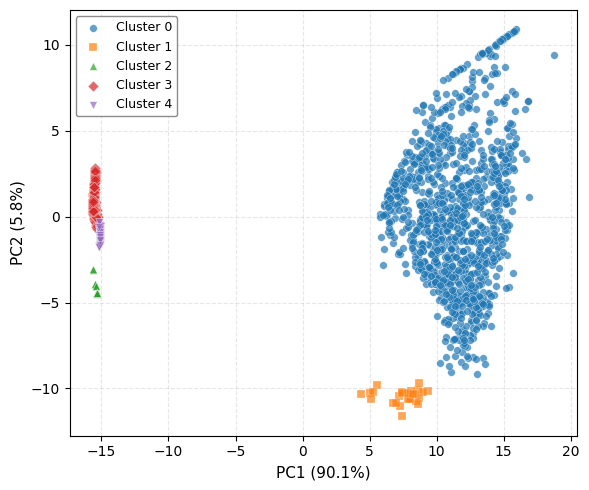

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_tsne_youtube_downlink.png
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_tsne_youtube_downlink.pdf


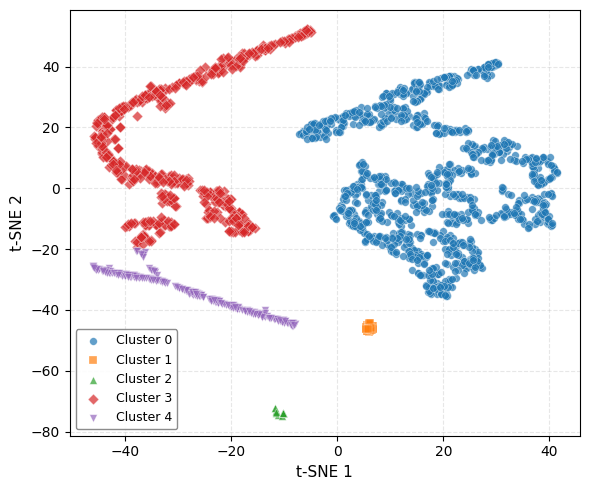

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pathlib import Path

def plot_2d_projection_with_clusters(df, feature_cols, label_col='cluster', sample_size=2000,
                                      save_path_pca=None, save_path_tsne=None):
    """
    Create 2D projections using PCA and t-SNE to visualize cluster quality
    """
    # Sample data if too large
    if len(df) > sample_size:
        df_sample = df.sample(n=sample_size, random_state=123)
    else:
        df_sample = df.copy()
    
    X = df_sample[feature_cols].values
    labels = df_sample[label_col].values
    
 
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # Define markers for better distinction
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h', '<', '>']
    
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # PCA projection
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # === FIGURE 1: PCA ===
    fig_pca, ax_pca = plt.subplots(figsize=(6, 5))
    
    for i, cluster_id in enumerate(unique_labels):
        mask = labels == cluster_id
        ax_pca.scatter(X_pca[mask, 0], X_pca[mask, 1],
                      label=f'Cluster {cluster_id}',
                      color=colors[i % len(colors)],
                      marker=markers[i % len(markers)],
                      alpha=0.7, s=30, edgecolors='white', linewidths=0.3)
    
    ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    ax_pca.tick_params(axis='both', which='major', labelsize=10)
    ax_pca.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='gray')
    ax_pca.grid(True, linestyle='--', alpha=0.3)
    ax_pca.set_axisbelow(True)
    
    fig_pca.tight_layout()
    
    # Save PCA figure
    if save_path_pca is not None:
        save_path_pca = Path(save_path_pca)
        save_path_pca.parent.mkdir(parents=True, exist_ok=True)
        fig_pca.savefig(save_path_pca.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig_pca.savefig(save_path_pca.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved: {save_path_pca.with_suffix('.png')}")
        print(f"Saved: {save_path_pca.with_suffix('.pdf')}")
    
    plt.show()
    
    # === FIGURE 2: t-SNE ===
    tsne = TSNE(n_components=2, random_state=123, perplexity=min(30, len(X)-1))
    X_tsne = tsne.fit_transform(X)
    
    fig_tsne, ax_tsne = plt.subplots(figsize=(6, 5))
    
    for i, cluster_id in enumerate(unique_labels):
        mask = labels == cluster_id
        ax_tsne.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                       label=f'Cluster {cluster_id}',
                       color=colors[i % len(colors)],
                       marker=markers[i % len(markers)],
                       alpha=0.7, s=30, edgecolors='white', linewidths=0.3)
    
    ax_tsne.set_xlabel('t-SNE 1', fontsize=11)
    ax_tsne.set_ylabel('t-SNE 2', fontsize=11)
    ax_tsne.tick_params(axis='both', which='major', labelsize=10)
    ax_tsne.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='gray')
    ax_tsne.grid(True, linestyle='--', alpha=0.3)
    ax_tsne.set_axisbelow(True)
    
    fig_tsne.tight_layout()
    
    # Save t-SNE figure
    if save_path_tsne is not None:
        save_path_tsne = Path(save_path_tsne)
        save_path_tsne.parent.mkdir(parents=True, exist_ok=True)
        fig_tsne.savefig(save_path_tsne.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig_tsne.savefig(save_path_tsne.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved: {save_path_tsne.with_suffix('.png')}")
        print(f"Saved: {save_path_tsne.with_suffix('.pdf')}")
    
    plt.show()

APP_ = globals().get("APP", "app")
DIR_ = globals().get("DIRECTION", "direction")

# Call the function
plot_2d_projection_with_clusters(
    core_all, 
    feature_cols,
    label_col='cluster_hdb_all',
    sample_size=2000,
    save_path_pca=FIG_DIR / f"fig_pca_{APP_}_{DIR_}",
    save_path_tsne=FIG_DIR / f"fig_tsne_{APP_}_{DIR_}"
)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, silhouette_samples

def cluster_diagnostics(df: pd.DataFrame,
                        feature_cols,
                        label_col: str = "cluster"):
    """
    Check cluster quality:

    - Per-cluster summary (mean/median/std of features)
    - Global and per-cluster silhouette
    - Distance matrix between cluster centers in feature space
    """
    # Make a copy so we can attach silhouette values
    df = df.copy()

    X = df[feature_cols].to_numpy()
    labels = df[label_col].to_numpy()

    # 1) Summary statistics per cluster 
    summary = (
        df.groupby(label_col)[feature_cols]
          .agg(["median", "mean", "std"])
          .sort_index()
    )
    print("=== Per-cluster summary (median/mean/std) ===")
    display(summary)

    # 2) Silhouette (separation vs cohesion) 
    # For HDBSCAN, we ignore noise points (label = -1) when computing silhouette
    mask = labels != -1
    X_clust = X[mask]
    lab_clust = labels[mask]

    if len(np.unique(lab_clust)) > 1:
        sil_global = silhouette_score(X_clust, lab_clust)
        sil_samples = silhouette_samples(X_clust, lab_clust)
        df["silhouette"] = np.nan
        df.loc[mask, "silhouette"] = sil_samples
    else:
        sil_global = np.nan
        df["silhouette"] = np.nan

    sil_by_cluster = (
        df.groupby(label_col)["silhouette"]
          .agg(["mean", "median", "min", "max", "count"])
          .sort_index()
    )

    print("\n=== Silhouette (clusters only, excluding noise) ===")
    print("Global silhouette score:", sil_global)
    print("\nPer-cluster silhouette stats:")
    display(sil_by_cluster)

    # 3) Distance between cluster centers
    centers = df.groupby(label_col)[feature_cols].mean().sort_index()
    center_vals = centers.to_numpy()

    # Euclidean distance between centers
    dist_matrix = np.linalg.norm(
        center_vals[:, None, :] - center_vals[None, :, :],
        axis=-1
    )

    dist_df = pd.DataFrame(
        dist_matrix,
        index=centers.index,
        columns=centers.index
    )

    print("\n=== Distance between cluster centers (Euclidean in feature space) ===")
    display(dist_df)

    return df, summary, sil_by_cluster, dist_df


In [48]:
# CLUSTER DIAGNOSTICS WITH ENHANCED FEATURES


# Use the ENHANCED feature set (must match what you used for clustering)
feature_cols_enhanced = [
    "log_on", "log_off", "log_packets", "log_bytes",
    "log_packet_rate", "log_byte_rate", "log_bytes_per_packet", "log_off_on_ratio",
    "is_first", "is_zero_on",
]

# Safety check: Ensure core_all has the enhanced features
missing_features = [f for f in feature_cols_enhanced if f not in core_all.columns]
if missing_features:
    print(f"WARNING: Enhanced features missing {missing_features}. Falling back to basic features.")
    feature_cols_used = [
        "log_on", "log_off", "log_packets", "log_bytes",
        "is_first", "is_zero_on",
    ]
else:
    feature_cols_used = feature_cols_enhanced
    print("✓ Using enhanced features for diagnostics")

print(f"\nRunning diagnostics with {len(feature_cols_used)} features...")
print(f"Features: {feature_cols_used}")

# Run comprehensive diagnostics
all_diag, all_summary, all_sil, all_dists = cluster_diagnostics(
    core_all, feature_cols_used, label_col="cluster_hdb_all"
)

# Print key insights
print("\n=== DIAGNOSTICS SUMMARY ===")
print(f"Silhouette scores by cluster:")
print(all_sil[['mean', 'median']].round(3))
print(f"\nCluster center distances:")
print(all_dists.round(2))

✓ Using enhanced features for diagnostics

Running diagnostics with 10 features...
Features: ['log_on', 'log_off', 'log_packets', 'log_bytes', 'log_packet_rate', 'log_byte_rate', 'log_bytes_per_packet', 'log_off_on_ratio', 'is_first', 'is_zero_on']
=== Per-cluster summary (median/mean/std) ===


log_on                        log_off                      \
                    median       mean       std    median      mean       std   
cluster_hdb_all                                                                 
0                -3.252368  -3.526300  1.854282 -1.755022 -1.028444  1.845362   
1                -5.702412  -5.507075  1.694742 -9.210340 -9.210340  0.000000   
2               -11.006108 -11.006108  0.000000 -9.210340 -9.210340  0.000000   
3               -11.006108 -11.006108  0.000000 -1.384364 -1.310629  1.160824   
4               -11.006108 -11.006108  0.000000 -1.903875 -1.783359  0.592669   

                log_packets                     log_bytes  ...  \
                     median      mean       std    median  ...   
cluster_hdb_all                                            ...   
0                  1.609438  2.135373  1.481403  7.972811  ...   
1                  1.098612  1.303357  0.641591  8.017472  ...   
2                  0.000000  0.000000  0.000000  7.163947  ...   
3                  0.000000  0.000000  0.000000  4.219508  ...   
4                  0.000000  0.000000  0.000000  7.163947  ...   

                log_bytes_per_packet log_off_on_ratio                      \
                                 std           median      mean       std   
cluster_hdb_all                                                             
0                           1.167321         1.964244  2.497857  2.882024   
1                           0.427986        -9.210340 -9.210340  0.000000   
2                           0.644982        -9.210340 -9.210340  0.000000   
3                           0.285416        -9.210340 -9.210340  0.000000   
4                           0.104512        -9.210340 -9.210340  0.000000   

                is_first           is_zero_on            
                  median mean  std     median mean  std  
cluster_hdb_all                                          
0                    0.0  0.0  0.0        0.0  0.0  0.0  
1                    1.0  1.0  0.0        0.0  0.0  0.0  
2                    1.0  1.0  0.0        1.0  1.0  0.0  
3                    0.0  0.0  0.0        1.0  1.0  0.0  
4                    0.0  0.0  0.0        1.0  1.0  0.0  

[5 rows x 30 columns]


=== Silhouette (clusters only, excluding noise) ===
Global silhouette score: 0.6309687430296737

Per-cluster silhouette stats:


,mean,median,min,max,count
cluster_hdb_all,,,,,
0,0.547765,0.563996,0.141185,0.668737,3632
1,0.780651,0.803369,0.634381,0.835218,102
2,0.901688,0.937941,0.605576,0.937941,117
3,0.682820,0.733431,-0.500132,0.789402,1975
4,0.836409,0.861152,0.484972,0.888749,744



=== Distance between cluster centers (Euclidean in feature space) ===


cluster_hdb_all,0,1,2,3,4
cluster_hdb_all,,,,,
0,0.000000,14.659494,27.884199,26.949384,26.643688
1,14.659494,0.000000,25.417677,26.999517,26.487906
2,27.884199,25.417677,0.000000,8.730064,7.505715
3,26.949384,26.999517,8.730064,0.000000,4.025927
4,26.643688,26.487906,7.505715,4.025927,0.000000



=== DIAGNOSTICS SUMMARY ===
Silhouette scores by cluster:
                  mean  median
cluster_hdb_all               
0                0.548   0.564
1                0.781   0.803
2                0.902   0.938
3                0.683   0.733
4                0.836   0.861

Cluster center distances:
cluster_hdb_all      0      1      2      3      4
cluster_hdb_all                                   
0                 0.00  14.66  27.88  26.95  26.64
1                14.66   0.00  25.42  27.00  26.49
2                27.88  25.42   0.00   8.73   7.51
3                26.95  27.00   8.73   0.00   4.03
4                26.64  26.49   7.51   4.03   0.00


## Empirical samplers

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union, Dict, Callable, Any



def make_empirical_sampler(x: pd.Series | np.ndarray):
    """
    Return a callable sampler that draws from the empirical distribution
    of the 1D data x (with replacement).

    NaNs and non-finite values are dropped.
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("No valid data for empirical sampler.")

    def sampler(n: int = 1, rng: Any = None) -> np.ndarray:
        rng = np.random.default_rng(rng)
        idx = rng.integers(0, x.size, size=n)
        return x[idx]

    return sampler


def make_on_sampler(on_values: pd.Series | np.ndarray):
    """
    Special case for ON durations:

    - preserve probability mass at 0 (zero-duration bursts),
    - sample positive ON durations empirically.
    """
    x = np.asarray(on_values, float)
    mask_zero = (x == 0.0)
    p0 = mask_zero.mean()
    x_pos = x[~mask_zero]
    if x_pos.size == 0:
        # Fallback if for some weird cluster all ON==0
        emp_pos = make_empirical_sampler(x)
        p0 = 0.0
    else:
        emp_pos = make_empirical_sampler(x_pos)

    def sampler(n: int = 1, rng: Any = None) -> np.ndarray:
        rng = np.random.default_rng(rng)
        u = rng.random(size=n)
        out = emp_pos(n, rng)
        out[u < p0] = 0.0
        return out

    return sampler


In [50]:
core_all.head()

,source_file,flow_id,burst_id,on_dur_s,off_dur_s,packets,bytes,t_start_s,t_end_s,flow_uid,...,log_off_on_ratio,is_zero_on,is_first,log_on,log_off,log_packets,log_bytes,cluster_hdb_all,cluster_strength,silhouette
0,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,0,0.069122,NaN,14,15611,7.901198,7.970320,Youtube_A_1_Final.csv||108.177.122.119>192.168...,...,-9.210340,0,1,-2.671882,-9.210340,2.639057,9.655731,1,0.459527,0.677158
1,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,1,0.016337,0.503272,3,1504,8.473592,8.489929,Youtube_A_1_Final.csv||108.177.122.119>192.168...,...,3.427698,0,0,-4.114323,-0.686624,1.098612,7.315884,0,1.000000,0.565895
2,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,2,0.054856,6.005242,15,17451,14.495171,14.550027,Youtube_A_1_Final.csv||108.177.122.119>192.168...,...,4.695676,0,0,-2.903044,1.792633,2.708050,9.767152,0,0.944616,0.539139
3,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,3,0.111286,0.790231,4,2722,15.340258,15.451544,Youtube_A_1_Final.csv||108.177.122.119>192.168...,...,1.960222,0,0,-2.195652,-0.235430,1.386294,7.909122,0,0.873527,0.552206
4,Youtube_A_1_Final.csv,108.177.122.119>192.168.137.169|QUIC,4,0.000000,0.883101,1,71,16.334645,16.334645,Youtube_A_1_Final.csv||108.177.122.119>192.168...,...,-9.210340,1,0,-11.006108,-0.124316,0.000000,4.262680,3,0.837622,0.728053


In [51]:
from scipy.stats import ks_2samp
import numpy as np

def compare_clusters(core_all, c0=0, c1=1, feature="bytes"):
    x0 = core_all.loc[core_all["cluster_hdb_all"] == c0, feature].to_numpy()
    x1 = core_all.loc[core_all["cluster_hdb_all"] == c1, feature].to_numpy()
    stat, p = ks_2samp(x0, x1)
    q0 = np.percentile(x0, [50, 90, 99])
    q1 = np.percentile(x1, [50, 90, 99])
    print(f"Feature: {feature}")
    print(f"KS(c{c0}, c{c1}) = {stat:.3f}, p = {p:.3g}")
    for q, r, s in zip([50, 90, 99], q0, q1):
        print(f"  q{q}: c{c0}={r:.4g}, c{c1}={s:.4g}")
    print()

for feat in ["on_dur_s", "bytes", "packets"]:
    compare_clusters(core_all, 0, 1, feature=feat)


Feature: on_dur_s
KS(c0, c1) = 0.484, p = 7.68e-22
  q50: c0=0.03868, c1=0.003338
  q90: c0=0.2255, c1=0.04747
  q99: c0=1.274, c1=0.09596

Feature: bytes
KS(c0, c1) = 0.370, p = 1.13e-12
  q50: c0=2901, c1=3034
  q90: c0=1.126e+05, c1=5778
  q99: c0=5.892e+05, c1=4.063e+04

Feature: packets
KS(c0, c1) = 0.299, p = 2.25e-08
  q50: c0=5, c1=3
  q90: c0=89.8, c1=9
  q99: c0=461.7, c1=32.89



In [52]:
split_cols = bursts_df[["flow_uid", "burst_id", "split"]]

core_all = (
    bursts_feat
    .merge(split_cols, on=["flow_uid", "burst_id"], how="left")
)

core_all = core_all[core_all["cluster_hdb_all"] != -1].copy()

core_train = core_all[core_all["split"] == "train"].copy()

core_test  = core_all[core_all["split"] == "test"].copy()

print(core_all["split"].value_counts())

split
train    4385
test     2185
Name: count, dtype: int64


In [53]:
cluster_models: Dict[int, Dict[str, Any]] = {}
total_bursts_core = len(core_train)   

for cid, g in core_train.groupby("cluster_hdb_all"):
    n = len(g)
    weight = n / total_bursts_core

    print(f"\nBuilding bootstrap model for cluster {cid} (n={n}, weight={weight:.3f})")

    # Work on a copy of the 4 core features
    g_feat = g[["on_dur_s", "off_dur_s", "bytes", "packets"]].copy()


    off_is_nan = g_feat["off_dur_s"].isna().to_numpy()

    # Clamp ON for logs
    on_is_zero = (g_feat["on_dur_s"].to_numpy() == 0.0)
    g_feat["on_dur_s"] = np.clip(g_feat["on_dur_s"].to_numpy(), eps_on, None)

    # OFF: replace NaN with eps_off just for logs
    g_feat["off_dur_s"] = g_feat["off_dur_s"].fillna(eps_off)
    g_feat["off_dur_s"] = np.clip(g_feat["off_dur_s"].to_numpy(), eps_off, None)

    # Bytes / packets must be strictly positive
    g_feat["bytes"]   = np.clip(g_feat["bytes"].to_numpy(),   1.0, None)
    g_feat["packets"] = np.clip(g_feat["packets"].to_numpy(), 1.0, None)

    # Log-space matrix: shape (n_bursts, 4)
    X_log = np.log(
        g_feat[["on_dur_s", "off_dur_s", "bytes", "packets"]].to_numpy()
    )

    # store valid log_off values (non-NaN OFF in training)
    valid_log_off = X_log[~off_is_nan, 1]   # column 1 is log_off

    model = {
        "cluster_id":    cid,
        "n_bursts":      n,
        "weight":        weight,
        "X_log":         X_log,
        "off_is_nan":    off_is_nan,
        "valid_log_off": valid_log_off,   
        "jitter": jitter_std_log,
        "on_is_zero": on_is_zero,
        "p_on_zero": float(on_is_zero.mean()),
        "on_stats":      g["on_dur_s"].describe(),
        "off_stats":     g["off_dur_s"].describe(),
        "bytes_stats":   g["bytes"].describe(),
        "pkts_stats":    g["packets"].describe(),
    }

    cluster_models[cid] = model

print("\nClusters modelled:", sorted(cluster_models.keys()))



Building bootstrap model for cluster 0 (n=2431, weight=0.554)

Building bootstrap model for cluster 1 (n=80, weight=0.018)

Building bootstrap model for cluster 2 (n=73, weight=0.017)

Building bootstrap model for cluster 3 (n=1397, weight=0.319)

Building bootstrap model for cluster 4 (n=404, weight=0.092)

Clusters modelled: [0, 1, 2, 3, 4]


In [54]:

def sample_burst_from_cluster(cluster_id: int,
                              rng: np.random.Generator,
                              need_valid_off: bool = False,
                              preserve_correlations: bool = True) -> dict:
    """
    Sample one synthetic burst from cluster_id 
    """
    model = cluster_models[cluster_id]
    X_log = model["X_log"]
    off_is_nan = model["off_is_nan"]
    valid_log_off = model["valid_log_off"]
    jitter = model["jitter"]
    on_is_zero = model["on_is_zero"]
    
    n_rows = X_log.shape[0]
    
    # robust sampling with fallback
    if need_valid_off:
        # Sample only from rows with valid OFF
        valid_indices = np.where(~off_is_nan)[0]
        if len(valid_indices) == 0:
            # Fallback: use all rows but will generate OFF later
            valid_indices = np.arange(n_rows)
    else:
        valid_indices = np.arange(n_rows)
    
    # Sample from valid indices
    i = int(rng.choice(valid_indices))
    
    # Get base values
    x = X_log[i].copy()
    
    # Apply correlated jitter (preserve feature relationships)
    if jitter > 0.0:
        if preserve_correlations:
            # Use multivariate normal with correlation structure
            cov_matrix = np.cov(X_log.T) * jitter**2
            try:
                jitter_vec = rng.multivariate_normal(np.zeros(len(x)), cov_matrix)
                x += jitter_vec
            except:
                # Fallback to independent jitter if singular
                x += rng.normal(scale=jitter, size=len(x))
        else:
            x += rng.normal(scale=jitter, size=len(x))
    
    # Extract features with better naming
    feature_names = ["log_on", "log_off", "log_bytes", "log_packets"]
    burst_features = dict(zip(feature_names, x))
    
    # Back-transform to real space
    on_dur = np.exp(burst_features["log_on"])
    if on_is_zero[i]:
        on_dur = 0.0
    
    off_dur = np.exp(burst_features["log_off"])
    bytes_val = np.exp(burst_features["log_bytes"])
    packets_val = np.exp(burst_features["log_packets"])
    
    # Handle OFF duration logic
    if off_is_nan[i]:
        if need_valid_off:
            # Sample from valid OFF distribution
            if len(valid_log_off) > 0:
                off_dur = np.exp(rng.choice(valid_log_off))
            else:
                off_dur = eps_off
        else:
            off_dur = np.nan
    else:
        off_dur = max(off_dur, 0.0)
    
    # Clamping and integer conversion
    if on_dur > 0:
        on_dur = max(on_dur, eps_on)
    bytes_val = max(bytes_val, 1.0)
    packets_val = int(max(round(packets_val), 1))
    
    return {
        "cluster": int(cluster_id),
        "on_dur_s": float(on_dur),
        "off_dur_s": off_dur,
        "bytes": float(bytes_val),
        "packets": packets_val,
        # Return enhanced features
        "packet_rate": packets_val / max(on_dur, eps_on) if on_dur > 0 else 0,
        "byte_rate": bytes_val / max(on_dur, eps_on) if on_dur > 0 else 0,
        "bytes_per_packet": bytes_val / packets_val if packets_val > 0 else 0,
    }

In [55]:
def sample_bursts_from_cluster(cluster_id: int,
                               n: int,
                               rng: int | np.random.Generator | None = None) -> pd.DataFrame:
    """
    Sample n bursts from a given cluster using sample_burst_from_cluster
    and return them as a DataFrame.
    """
    # Allow passing a seed or a Generator
    if isinstance(rng, (int, np.integer)) or rng is None:
        rng = np.random.default_rng(rng)

    records = []
    for _ in range(n):
        b = sample_burst_from_cluster(cluster_id, rng)
        records.append(b)

    return pd.DataFrame.from_records(records)


In [56]:
from scipy.stats import ks_2samp

def validate_cluster(cluster_id: int, rng: int = 123, n_sample: int = 5000) -> pd.DataFrame:
    """
    For one cluster, compare real vs synthetic for each feature
    using 2-sample KS and selected quantiles.
    """
    if cluster_id not in cluster_models:
        raise KeyError(f"No model for cluster {cluster_id}")

    m = cluster_models[cluster_id]

    real = core_all[core_all["cluster_hdb_all"] == cluster_id]
    synth = sample_bursts_from_cluster(cluster_id, n_sample, rng=rng)

    rows = []
    for col in ["on_dur_s", "off_dur_s", "bytes", "packets"]:
        real_col  = real[col]
        synth_col = synth[col]

        # Drop NaNs
        real_vals  = real_col.dropna().to_numpy(dtype=float)
        synth_vals = synth_col.dropna().to_numpy(dtype=float)

        # If this cluster has no real OFF, skip OFF validation
        if col == "off_dur_s" and real_vals.size == 0:
            rows.append({
                "cluster":    cluster_id,
                "feature":    col,
                "ks_stat":    np.nan,
                "ks_p":       np.nan,
                "q50_real":   np.nan,
                "q50_syn":    np.nan,
                "q50_rel_err": np.nan,
                "q90_real":   np.nan,
                "q90_syn":    np.nan,
                "q90_rel_err": np.nan,
                "q99_real":   np.nan,
                "q99_syn":    np.nan,
                "q99_rel_err": np.nan,
            })
            continue

        if real_vals.size == 0 or synth_vals.size == 0:
            # Shouldn't happen except perhaps for pathological data
            ks_stat = np.nan
            ks_p    = np.nan
        else:
            ks_res  = ks_2samp(real_vals, synth_vals)
            ks_stat = ks_res.statistic
            ks_p    = ks_res.pvalue

        def q(arr, p):
            return np.quantile(arr, p) if arr.size > 0 else np.nan

        q50_r, q90_r, q99_r = q(real_vals, 0.5), q(real_vals, 0.9), q(real_vals, 0.99)
        q50_s, q90_s, q99_s = q(synth_vals, 0.5), q(synth_vals, 0.9), q(synth_vals, 0.99)

        def rel_err(r, s):
            return (s - r) / r if (r not in (0, np.nan) and np.isfinite(r)) else np.nan

        rows.append({
            "cluster":     cluster_id,
            "feature":     col,
            "ks_stat":     ks_stat,
            "ks_p":        ks_p,
            "q50_real":    q50_r,
            "q50_syn":     q50_s,
            "q50_rel_err": rel_err(q50_r, q50_s),
            "q90_real":    q90_r,
            "q90_syn":     q90_s,
            "q90_rel_err": rel_err(q90_r, q90_s),
            "q99_real":    q99_r,
            "q99_syn":     q99_s,
            "q99_rel_err": rel_err(q99_r, q99_s),
        })

    return pd.DataFrame(rows)


In [57]:
import numpy as np
import pandas as pd

def sample_global_bursts(n_total: int, rng: int = 123) -> pd.DataFrame:
    """
    Sample n_total bursts from the global mixture of clusters.

    - Cluster IDs are drawn according to empirical cluster weights.
    - For each cluster, we call sample_bursts_from_cluster with its share.
    """
    base_rng = np.random.default_rng(rng)

    # Sorted list of cluster IDs
    cluster_ids = np.array(sorted(cluster_models.keys()))
    weights = np.array([cluster_models[c]["weight"] for c in cluster_ids], dtype=float)
    weights = weights / weights.sum()  # safety

    # Draw cluster assignments for each synthetic burst
    assigned = base_rng.choice(cluster_ids, size=n_total, p=weights)

    dfs = []
    for c in cluster_ids:
        k = int((assigned == c).sum())
        if k == 0:
            continue

        # draw a fresh integer seed for this cluster; per-cluster sampler expects an int
        seed_c = int(base_rng.integers(0, 2**32 - 1))
        df_c = sample_bursts_from_cluster(c, n=k, rng=seed_c)
        dfs.append(df_c)

    synth_all = pd.concat(dfs, ignore_index=True)
    return synth_all


In [58]:
# Real bursts from the core (all clusters, no noise)
real_all = core_all[["on_dur_s", "off_dur_s", "bytes", "packets"]].copy()

# Same number of synthetic bursts
synth_all = sample_global_bursts(n_total=len(real_all), rng=2025)
synth_all.head()


,cluster,on_dur_s,off_dur_s,bytes,packets,packet_rate,byte_rate,bytes_per_packet
0,0,0.004593,0.101673,1828.126670,3,653.236738,398066.500858,609.375557
1,0,0.003162,0.119556,434.310677,6,1897.680548,137363.820703,72.385113
2,0,0.064029,80.167294,2164.759330,6,93.708159,33809.268600,360.793222
3,0,0.011778,0.260025,134.042003,2,169.811098,11380.909868,67.021002
4,0,0.153180,0.115088,3727.682779,5,32.641368,24335.333423,745.536556


In [59]:
from scipy.stats import ks_2samp

def validate_global(real: pd.DataFrame,
                    synth: pd.DataFrame) -> pd.DataFrame:
    """
    Compare real vs synthetic bursts at the global level (all clusters mixed).
    """
    rows = []

    for col in ["on_dur_s", "off_dur_s", "bytes", "packets"]:
        r = real[col].dropna().to_numpy(dtype=float)
        s = synth[col].dropna().to_numpy(dtype=float)

        if r.size == 0 or s.size == 0:
            ks_stat, ks_p = np.nan, np.nan
        else:
            ks_res = ks_2samp(r, s)
            ks_stat, ks_p = ks_res.statistic, ks_res.pvalue

        def q(arr, p):
            return np.quantile(arr, p) if arr.size > 0 else np.nan

        q50_r, q90_r, q99_r = q(r, 0.5), q(r, 0.9), q(r, 0.99)
        q50_s, q90_s, q99_s = q(s, 0.5), q(s, 0.9), q(s, 0.99)

        def rel_err(a, b):
            return (b - a) / a if (np.isfinite(a) and a != 0) else np.nan

        rows.append({
            "feature": col,
            "ks_stat": ks_stat,
            "ks_p":    ks_p,
            "q50_real": q50_r,
            "q50_syn":  q50_s,
            "q50_rel_err": rel_err(q50_r, q50_s),
            "q90_real": q90_r,
            "q90_syn":  q90_s,
            "q90_rel_err": rel_err(q90_r, q90_s),
            "q99_real": q99_r,
            "q99_syn":  q99_s,
            "q99_rel_err": rel_err(q99_r, q99_s),
        })

    return pd.DataFrame(rows)


### attach split to the core_all

In [60]:
global_val = validate_global(real_all, synth_all)
global_val


,feature,ks_stat,ks_p,q50_real,q50_syn,q50_rel_err,q90_real,q90_syn,q90_rel_err,q99_real,q99_syn,q99_rel_err
0,on_dur_s,0.006545,9.989613e-01,0.001971,0.002081,0.055601,0.145000,0.144510,-0.003379,0.998670,1.018456,0.019812
1,off_dur_s,0.038859,1.332627e-04,0.191139,0.213558,0.117290,3.971743,4.976124,0.252882,28.592629,29.617715,0.035851
2,bytes,0.096956,2.744654e-27,1292.000000,671.888038,-0.479963,48585.700000,43034.373385,-0.114258,377918.690000,496973.787364,0.315028
3,packets,0.012177,7.147716e-01,2.000000,2.000000,0.000000,40.000000,36.000000,-0.100000,294.550000,384.620000,0.305788


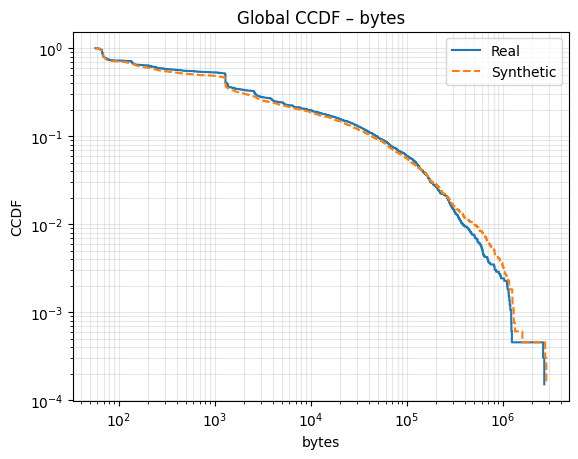

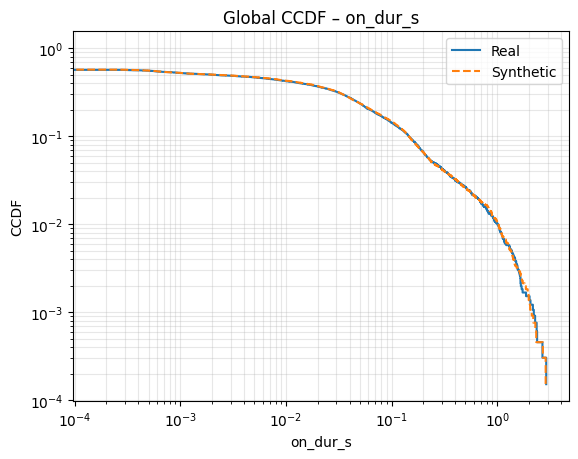

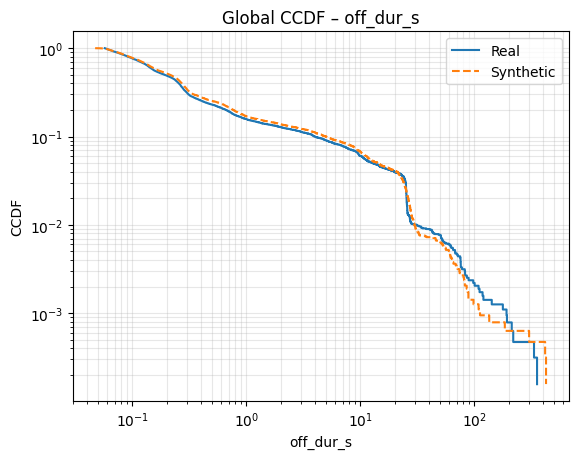

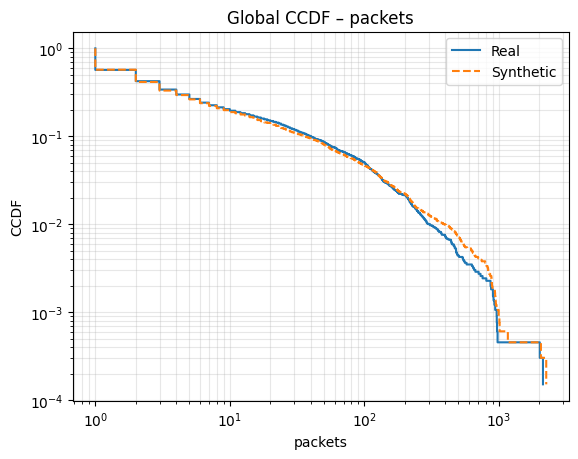

In [61]:
import matplotlib.pyplot as plt

def plot_global_ccdf(real: pd.Series,
                     synth: pd.Series,
                     feature_name: str,
                     logx: bool = True):
    r = real.dropna().to_numpy(dtype=float)
    s = synth.dropna().to_numpy(dtype=float)

    def ccdf(x):
        x_sorted = np.sort(x)
        n = len(x_sorted)
        y = 1.0 - np.arange(1, n + 1) / (n + 1)
        return x_sorted, y

    xr, yr = ccdf(r)
    xs, ys = ccdf(s)

    plt.figure()
    plt.step(xr, yr, where="post", label="Real")
    plt.step(xs, ys, where="post", linestyle="--", label="Synthetic")
    if logx:
        plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(feature_name)
    plt.ylabel("CCDF")
    plt.title(f"Global CCDF – {feature_name}")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# Example for bytes and ON duration:
plot_global_ccdf(real_all["bytes"],   synth_all["bytes"],   "bytes")
plot_global_ccdf(real_all["on_dur_s"], synth_all["on_dur_s"], "on_dur_s")
plot_global_ccdf(real_all["off_dur_s"], synth_all["off_dur_s"], "off_dur_s")
plot_global_ccdf(real_all["packets"], synth_all["packets"], "packets")


# 9. Markov model 

In [62]:
def compute_cluster_markov(df: pd.DataFrame, alpha: float = 1e-3) -> dict:

    """
    Build a first-order Markov model over cluster_hdb_all: the train only
    from a bursts DataFrame with columns:
      - flow_uid
      - t_start_s
      - cluster_hdb_all
    """
    # sort by flow instance & time
    df = df.sort_values(["flow_uid", "t_start_s"]).copy()

    alpha = float(alpha)
    if alpha < 0:
        raise ValueError("alpha must be >= 0")


    # set of cluster labels and index mapping
    clusters = np.sort(df["cluster_hdb_all"].unique())
    K = len(clusters)
    idx = {c: i for i, c in enumerate(clusters)}

    # raw counts
    trans_counts = np.zeros((K, K), dtype=float)
    init_counts  = np.zeros(K, dtype=float)

    # iterate per flow instance
    for fuid, g in df.groupby("flow_uid"):
        seq = g["cluster_hdb_all"].to_numpy()
        if len(seq) == 0:
            continue

        # initial state of this flow
        init_counts[idx[seq[0]]] += 1

        # transitions inside this flow
        for a, b in zip(seq[:-1], seq[1:]):
            ia = idx[a]
            ib = idx[b]
            trans_counts[ia, ib] += 1

    # initial distribution pi
    if init_counts.sum() > 0:
        pi = (init_counts + alpha) / (init_counts.sum() + alpha * K)
    else:
        pi = np.ones(K, dtype=float) / K


    # row-stochastic transition matrix P
    P = trans_counts.copy()
    row_sums = P.sum(axis=1, keepdims=True)

    for k in range(K):
        row = P[k, :]
        s = row.sum()
        if s > 0:
            P[k, :] = (row + alpha) / (s + alpha * K)
        else:
            P[k, :] = pi


    # empirical distribution of flow lengths (in bursts), per flow_uid
    flow_lengths = (
        df.groupby("flow_uid")["cluster_hdb_all"]
          .size()
          .to_numpy()
    )

    return {
        "clusters": clusters,
        "P": P,
        "pi": pi,
        "flow_lengths": flow_lengths,
        "alpha": alpha,
    }


In [63]:
# fit Markov model on TRAIN ONLY
markov_model = compute_cluster_markov(core_train, alpha=1e-3)
print("alpha:", markov_model["alpha"])
print("clusters:", markov_model["clusters"])
print("P shape:", markov_model["P"].shape)
print("diag(P) (stickiness):", np.diag(markov_model["P"]))


alpha: 0.001
clusters: [0 1 2 3 4]
P shape: (5, 5)
diag(P) (stickiness): [5.44919511e-01 1.85168040e-05 1.40835152e-05 3.32834208e-01
 2.42893503e-01]


In [64]:
from hdbscan import validity

# On TRAIN ONLY:
X_train_hdb = X_train_std  
labels_train = bursts_feat.loc[train_mask, "cluster_hdb_all"].to_numpy()

dbcv_train = validity.validity_index(X_train_hdb, labels_train)
print("DBCV (train only):", dbcv_train)


DBCV (train only): 0.4284176464637211


### Sample cluster sequences from the Markov model

In [65]:
def sample_cluster_sequence_markov(T: int, model: dict, rng: int | None = 123) -> np.ndarray:
    """
    Sample a cluster sequence of length T from the fitted Markov model.
    """
    rng = np.random.default_rng(rng)
    clusters = model["clusters"]
    P = model["P"]
    pi = model["pi"]
    idx = {c: i for i, c in enumerate(clusters)}

    seq_idx = np.empty(T, dtype=int)
    # initial state
    seq_idx[0] = rng.choice(len(clusters), p=pi)
    # transitions
    for t in range(1, T):
        i = seq_idx[t-1]
        seq_idx[t] = rng.choice(len(clusters), p=P[i])

    return clusters[seq_idx]


Quick sanity check on run lengths:

In [66]:
def run_lengths(cluster_seq: np.ndarray) -> pd.DataFrame:
    if len(cluster_seq) == 0:
        return pd.DataFrame(columns=["cluster", "run_len"])
    runs = []
    cur = cluster_seq[0]
    length = 1
    for c in cluster_seq[1:]:
        if c == cur:
            length += 1
        else:
            runs.append((cur, length))
            cur = c
            length = 1
    runs.append((cur, length))
    return pd.DataFrame(runs, columns=["cluster", "run_len"])


# Real sequence (TRAIN only)
real_seq = (
    core_train.sort_values(["flow_uid", "t_start_s"])["cluster_hdb_all"]
    .to_numpy()
)
real_runs = run_lengths(real_seq)

# Synthetic sequence from Markov
T = len(real_seq)
synthetic_seq = sample_cluster_sequence_markov(T, markov_model, rng=123)
synthetic_runs = run_lengths(synthetic_seq)

real_run_stats = (
    real_runs.groupby("cluster")["run_len"]
    .describe(percentiles=[0.5, 0.9, 0.99])
)
synthetic_run_stats = (
    synthetic_runs.groupby("cluster")["run_len"]
    .describe(percentiles=[0.5, 0.9, 0.99])
)

print("REAL run lengths:")
print(real_run_stats)
print("\nSYNTHETIC run lengths (Markov):")
print(synthetic_run_stats)


REAL run lengths:
          count      mean       std  min  50%  90%   99%   max
cluster                                                       
0        1133.0  2.145631  1.935572  1.0  1.0  4.0  9.00  20.0
1          62.0  1.290323  0.611022  1.0  1.0  2.0  3.39   4.0
2          73.0  1.000000  0.000000  1.0  1.0  1.0  1.00   1.0
3         952.0  1.467437  0.844971  1.0  1.0  2.0  5.00   8.0
4         310.0  1.303226  0.627051  1.0  1.0  2.0  4.00   5.0

SYNTHETIC run lengths (Markov):
          count      mean       std  min  50%  90%  99%   max
cluster                                                      
0        1134.0  2.235450  1.633210  1.0  2.0  4.0  8.0  12.0
2           1.0  1.000000       NaN  1.0  1.0  1.0  1.0   1.0
3        1003.0  1.447657  0.777684  1.0  1.0  2.0  4.0   6.0
4         300.0  1.323333  0.678471  1.0  1.0  2.0  4.0   5.0


### Markov-driven burst generator + global validation

In [67]:
def sample_global_bursts_markov(n_total: int,
                                model: dict,
                                rng: int | None = 123) -> pd.DataFrame:
    """
    Sample ~n_total bursts from the Markov model, but:
      - generate traffic as a set of synthetic flows,
      - each flow length (in bursts) is sampled from the empirical
        flow_lengths distribution (TRAIN),
      - the Markov chain is RESET at each flow (start from pi),
      - we stop when we reach n_total bursts (last flow may be truncated).

    """
    base_rng = np.random.default_rng(rng)

    flow_lengths = model["flow_lengths"]
    if len(flow_lengths) == 0:
        raise ValueError("No flow_lengths in markov_model")

    records = []
    total = 0
    syn_flow_id = 0

    while total < n_total:
        # 1) sample a flow length from empirical distribution
        L = int(base_rng.choice(flow_lengths))
        if L <= 0:
            continue  # very defensive
            
        # 2) sample a cluster sequence of length L, RESETTING the chain
        cluster_seq = sample_cluster_sequence_markov(
            L,
            model,
            rng=int(base_rng.integers(0, 2**32 - 1)),
        )

        # 3) turn that into bursts, but stop at n_total
        for j, c in enumerate(cluster_seq):
            if total >= n_total:
                break
            need_valid_off = (j > 0)
            row = sample_burst_from_cluster(
                int(c),
                rng=np.random.default_rng(int(base_rng.integers(0, 2**32 - 1))),
                need_valid_off=need_valid_off,
            )
            
            if j == 0:
                row["off_dur_s"] = np.nan
            
            row["synthetic_flow_id"] = syn_flow_id
            row["synthetic_burst_idx"] = j
            
            records.append(row)
            total += 1

        syn_flow_id += 1  

    synth = pd.DataFrame.from_records(records)
    return synth


# Compare TRAIN real vs Markov synthetic globally
real_train = core_train[["on_dur_s", "off_dur_s", "bytes", "packets"]].copy()
synth_markov = sample_global_bursts_markov(len(real_train), markov_model, rng=2026)

global_val_markov = validate_global(real_train, synth_markov)
global_val_markov


,feature,ks_stat,ks_p,q50_real,q50_syn,q50_rel_err,q90_real,q90_syn,q90_rel_err,q99_real,q99_syn,q99_rel_err
0,on_dur_s,0.015964,0.631472,0.002094,0.002982,0.423834,0.142341,0.145925,0.025180,1.013295,0.999386,-0.013727
1,off_dur_s,0.017321,0.539578,0.215084,0.220602,0.025658,4.750671,4.562599,-0.039589,30.505184,34.245889,0.122625
2,bytes,0.050627,0.000026,591.000000,591.363285,0.000615,44744.800000,51486.443870,0.150669,509018.240000,450205.560487,-0.115541
3,packets,0.016648,0.577860,2.000000,2.000000,0.000000,37.000000,42.600000,0.151351,399.800000,351.320000,-0.121261


Evaluate on held-out flows (real_val / real_test)

In [68]:
# Evaluate on test set 
real_test = core_test[["on_dur_s","off_dur_s","bytes","packets"]].copy()
synth_test_markov = sample_global_bursts_markov(len(real_test), markov_model, rng=2027)
global_test_markov = validate_global(real_test, synth_test_markov)
display(global_test_markov)

,feature,ks_stat,ks_p,q50_real,q50_syn,q50_rel_err,q90_real,q90_syn,q90_rel_err,q99_real,q99_syn,q99_rel_err
0,on_dur_s,0.031121,2.405803e-01,0.001730,0.002915,0.684781,0.153163,0.139591,-0.088609,0.916031,1.003709,0.095714
1,off_dur_s,0.112495,4.149287e-12,0.160578,0.208956,0.301272,2.444621,4.750671,0.943316,27.282536,31.973962,0.171957
2,bytes,0.196339,3.094045e-37,1292.000000,694.900320,-0.462151,54131.200000,43341.016110,-0.199334,304429.480000,470068.864930,0.544098
3,packets,0.034325,1.523492e-01,2.000000,2.000000,0.000000,43.600000,35.600000,-0.183486,243.160000,382.680000,0.573779


In [69]:
def sample_markov_batch(n_test: int, markov_model: dict, n_rep: int = 20, rng_seed: int = 42):
    import numpy as np
    rng = np.random.default_rng(rng_seed)
    stats = []
    for i in range(n_rep):
        synth = sample_global_bursts_markov(n_test, markov_model, rng=int(rng.integers(0, 2**32-1)))
        q50 = np.quantile(synth["bytes"], 0.5)
        q90 = np.quantile(synth["bytes"], 0.9)
        q99 = np.quantile(synth["bytes"], 0.99)
        stats.append((q50, q90, q99))
    return pd.DataFrame(stats, columns=["q50", "q90", "q99"])

synth_stats = sample_markov_batch(len(real_test), markov_model, n_rep=30)
real_qs = np.quantile(real_test["bytes"], [0.5, 0.9, 0.99])
print("Real test bytes quantiles:", real_qs)
display(synth_stats.describe())

Real test bytes quantiles: [  1292.    54131.2  304429.48]


,q50,q90,q99
count,30.000000,30.000000,30.000000
mean,626.337953,42903.933606,479322.179119
std,172.074642,4746.047582,77899.422169
min,375.313572,32173.702487,369233.864295
25%,495.227917,40211.261859,408287.296446
50%,611.314381,42857.079509,477312.941345
75%,700.348454,46900.573547,529465.638007
max,1069.677108,51259.498333,636888.281019


In [70]:
synth = sample_global_bursts_markov(n_total=5000, model=markov_model, rng=2027)

# First burst in every synthetic flow must have off_dur_s = NaN
first = (synth.sort_values(["synthetic_flow_id","synthetic_burst_idx"])
              .groupby("synthetic_flow_id")
              .first())
print("First-burst OFF NaN fraction:", first["off_dur_s"].isna().mean())

# Non-first bursts should almost never be NaN (ideally 0)
rest = synth[synth["synthetic_burst_idx"] > 0]
print("Non-first OFF NaN fraction:", rest["off_dur_s"].isna().mean())


First-burst OFF NaN fraction: 0.17582417582417584
Non-first OFF NaN fraction: 0.0


In [71]:
first_bursts = synth[synth["synthetic_burst_idx"] == 0]
print("First-burst OFF NaN fraction:", first_bursts["off_dur_s"].isna().mean())

rest = synth[synth["synthetic_burst_idx"] > 0]
print("Non-first OFF NaN fraction:", rest["off_dur_s"].isna().mean())
ordered = synth.sort_values(["synthetic_flow_id", "synthetic_burst_idx"])
first = ordered.groupby("synthetic_flow_id").nth(0)  # keeps NaN
print("First-burst OFF NaN fraction:", first["off_dur_s"].isna().mean())


First-burst OFF NaN fraction: 1.0
Non-first OFF NaN fraction: 0.0
First-burst OFF NaN fraction: 1.0


# 10. Save Output tables and plots 

In [72]:
from __future__ import annotations

import json
import pprint
import platform
import sys
from pathlib import Path
from typing import Any, Optional, Dict

import numpy as np
import pandas as pd


PROJECT_ROOT = Path("..").resolve()
ART_ROOT = PROJECT_ROOT / "artifacts"


required = ["APP", "DIRECTION", "RUN_ID"]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required globals: {missing}. Define APP, DIRECTION, RUN_ID first.")

RUN_DIR = ART_ROOT / str(APP) / str(DIRECTION) / f"run_{RUN_ID}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

def OUT(*parts: str) -> Path:

    p = RUN_DIR.joinpath(*map(str, parts))
    p.parent.mkdir(parents=True, exist_ok=True)
    return p


PAPER_DIR = OUT("paper")
TABLE_DIR = OUT("paper", "tables")
FIG_DIR   = OUT("paper", "figs")
DATA_DIR  = OUT("data")  

for d in [PAPER_DIR, TABLE_DIR, FIG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def json_safe(x: Any, _seen: Optional[set] = None) -> Any:
    """Convert objects into JSON-serializable structures """
    if _seen is None:
        _seen = set()

    if x is None or isinstance(x, (bool, int, float, str)):
        return x

    if isinstance(x, (np.integer, np.floating)):
        return x.item()

    if isinstance(x, Path):
        return str(x)

    oid = id(x)
    if oid in _seen:
        return "<circular>"
    _seen.add(oid)

    if isinstance(x, np.ndarray):
        return x.tolist()

    if isinstance(x, (list, tuple, set)):
        return [json_safe(v, _seen) for v in x]

    if isinstance(x, dict):
        return {str(k): json_safe(v, _seen) for k, v in x.items()}

    return str(x)

def save_json(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_safe(obj), indent=2), encoding="utf-8")

def sanitize_params(params: dict, drop_keys: Optional[set] = None) -> dict:
    drop_keys = set(drop_keys or [])
    return {k: json_safe(v) for k, v in params.items() if k not in drop_keys}

def save_table(df: pd.DataFrame, stem: str) -> tuple[Path, Path]:

    csv_path = TABLE_DIR / f"{stem}.csv"
    tex_path = TABLE_DIR / f"{stem}.tex"
    df.to_csv(csv_path, index=False)
    try:
        df.to_latex(tex_path, index=False, escape=False, float_format="%.6g")
    except Exception:

        pass
    return csv_path, tex_path

def get_versions() -> dict:
    v = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": getattr(np, "__version__", None),
        "pandas": getattr(pd, "__version__", None),
    }

    try:
        import sklearn  
        v["scikit_learn"] = sklearn.__version__
    except Exception:
        pass
    try:
        import hdbscan  
        v["hdbscan"] = hdbscan.__version__
    except Exception:
        pass
    return v


In [73]:
import json
from datetime import datetime


manifest = {
    "app": str(APP),
    "direction": str(DIRECTION),
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "hyperparameters": {
        "theta_seconds": float(theta),
        "theta_clip_s": [0.02, 1.5],  
        "eps_on": float(eps_on),
        "eps_off": float(eps_off),
        "jitter_std_log": float(jitter_std_log),
        "hdbscan_params": {
            "min_cluster_size": int(min_cluster_size),
            "min_samples": int(min_samples),
            "cluster_selection_method": str(cluster_selection_method),
        },
    },
    "paths": {
        "out_dir": str(OUT_DIR),
        "bursts_parquet": str(OUT_DIR / "bursts_df.parquet"),
        "flows_parquet": str(OUT_DIR / "flows.parquet"),
    },
}

manifest_path = OUT_DIR / "run_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Wrote:", manifest_path)


Wrote: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/run_manifest.json


In [74]:
from typing import List, Tuple

def latest_run_dir(dir_root: Path) -> Optional[Path]:
    runs = sorted([p for p in dir_root.glob("run_*") if p.is_dir()])
    return runs[-1] if runs else None

def load_latest_manifests(art_root: Path, apps: List[str], direction: str) -> Tuple[pd.DataFrame, List[Tuple[str, str]]]:
    rows = []
    missing: List[Tuple[str, str]] = []

    for app in apps:
        dir_root = art_root / app / direction
        if not dir_root.exists():
            missing.append((app, f"missing folder: {dir_root}"))
            continue

        run_dir = latest_run_dir(dir_root)
        if run_dir is None:
            missing.append((app, f"no run_* under: {dir_root}"))
            continue

        mpath = run_dir / "run_manifest.json"
        if not mpath.exists():
            missing.append((app, f"missing: {mpath}"))
            continue

        m = json.loads(mpath.read_text(encoding="utf-8"))
        hp = m.get("hyperparameters", {}) or {}
        hdb = hp.get("hdbscan_params") or {}

        rows.append({
            "app": app,
            "direction": direction,
            "theta_s": hp.get("theta_seconds"),
            "theta_clip_s": hp.get("theta_clip_s"),
            "eps_on": hp.get("eps_on"),
            "eps_off": hp.get("eps_off"),
            "min_cluster_size": hdb.get("min_cluster_size"),
            "min_samples": hdb.get("min_samples"),
            "jitter_std_log": hp.get("jitter_std_log"),
            "run_dir": str(run_dir),
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("app").reset_index(drop=True)

    return df, missing

# Example
APPS = ["youtube", "igap", "aparat", "filimo", "telegram"]
summary_df, missing = load_latest_manifests(ART_ROOT, APPS, DIRECTION)

if missing:
    print("Some apps were skipped:")
    for app, reason in missing:
        print(f" - {app}: {reason}")

summary_df


Some apps were skipped:
 - aparat: missing folder: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/aparat/downlink
 - telegram: missing folder: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/telegram/downlink


,app,direction,theta_s,theta_clip_s,eps_on,eps_off,min_cluster_size,min_samples,jitter_std_log,run_dir
0,filimo,downlink,0.020000,"[0.02, 1.5]",0.000003,0.0001,40,25,0.04,/Users/ghinwaismail/Desktop/trafficgen-paper/a...
1,igap,downlink,0.041007,"[0.02, 1.5]",0.000003,0.0001,15,15,0.05,/Users/ghinwaismail/Desktop/trafficgen-paper/a...
2,youtube,downlink,0.057164,"[0.02, 1.5]",0.000017,0.0001,50,25,0.05,/Users/ghinwaismail/Desktop/trafficgen-paper/a...


In [75]:
if summary_df is None or summary_df.empty:
    print("No run_manifest.json found yet for the requested apps/direction.")
    print("Fix: write run_manifest.json at the end of each per-app run, then rerun this cell.")
    # Create an empty table with expected columns 
    summary_df = pd.DataFrame(columns=[
        "app", "direction", "theta_s", "theta_clip_s", "eps_on", "eps_off",
        "min_cluster_size", "min_samples", "jitter_std_log", "run_dir"
    ])


df_tbl = summary_df.copy()


df_tbl["theta_s"] = pd.to_numeric(df_tbl["theta_s"], errors="coerce").map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
df_tbl["eps_on"]  = pd.to_numeric(df_tbl["eps_on"],  errors="coerce").map(lambda x: "" if pd.isna(x) else f"{x:.1e}")
df_tbl["eps_off"] = pd.to_numeric(df_tbl["eps_off"], errors="coerce").map(lambda x: "" if pd.isna(x) else f"{x:.1e}")
df_tbl["jitter_std_log"] = pd.to_numeric(df_tbl["jitter_std_log"], errors="coerce").map(lambda x: "" if pd.isna(x) else f"{x:.2f}")


df_tbl["min_cluster_size"] = pd.to_numeric(df_tbl["min_cluster_size"], errors="coerce").map(lambda x: "" if pd.isna(x) else str(int(round(float(x)))))
df_tbl["min_samples"]      = pd.to_numeric(df_tbl["min_samples"],      errors="coerce").map(lambda x: "" if pd.isna(x) else str(int(round(float(x)))))

df_paper = df_tbl.rename(columns={
    "app": "Application",
    "direction": "Direction",
    "theta_s": r"$\theta$ (s)",
    "theta_clip_s": r"$\theta$ clip (s)",
    "eps_on": r"$\epsilon_{on}$",
    "eps_off": r"$\epsilon_{off}$",
    "jitter_std_log": r"$\sigma_{jit}$",
})

df_paper = df_paper[[
    "Application", "Direction",
    r"$\theta$ (s)", r"$\theta$ clip (s)",
    r"$\epsilon_{on}$", r"$\epsilon_{off}$",
    "min_cluster_size", "min_samples",
    r"$\sigma_{jit}$",
]]


try:
    from IPython.display import display
    display(df_paper.style.hide(axis="index"))
except Exception:
    print(df_paper)


csv_path, tex_path = save_table(df_paper, stem=f"table_hparams_per_app_{DIRECTION}")
print("Saved:", csv_path)
print("Saved:", tex_path)


Application,Direction,$\theta$ (s),$\theta$ clip (s),$\epsilon_{on}$,$\epsilon_{off}$,min_cluster_size,min_samples,$\sigma_{jit}$
filimo,downlink,0.020,"[0.02, 1.5]",2.8e-06,1.0e-04,40,25,0.04
igap,downlink,0.041,"[0.02, 1.5]",3.1e-06,1.0e-04,15,15,0.05
youtube,downlink,0.057,"[0.02, 1.5]",1.7e-05,1.0e-04,50,25,0.05


Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/table_hparams_per_app_downlink.csv
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/table_hparams_per_app_downlink.tex


In [76]:
import matplotlib.pyplot as plt

def ecdf(x: pd.Series):
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy()
    if x.size == 0:
        return np.array([]), np.array([])
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

def plot_ecdf(ax, real: pd.Series, synth: pd.Series, xlabel: str, logx: bool = False):
    xr, yr = ecdf(real)
    xs, ys = ecdf(synth)

    if xr.size:
        ax.step(xr, yr, where="post", label="Real")
    if xs.size:
        ax.step(xs, ys, where="post", linestyle="--", label="Synthetic")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=":", linewidth=0.6)

    if logx:
        ax.set_xscale("log")

def plot_app_cdf_grid(app_name: str, real_df: pd.DataFrame, synth_df: pd.DataFrame, stem: str):
    fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True)
    axes = axes.ravel()

    plot_ecdf(axes[0], real_df["on_dur_s"],  synth_df["on_dur_s"],  "ON duration (s)",  logx=True)
    axes[0].set_title("ON duration")

    plot_ecdf(axes[1], real_df["off_dur_s"], synth_df["off_dur_s"], "OFF duration (s)", logx=True)
    axes[1].set_title("OFF duration")

    plot_ecdf(axes[2], real_df["packets"],   synth_df["packets"],   "Packets per burst", logx=True)
    axes[2].set_title("Packets")

    plot_ecdf(axes[3], real_df["bytes"],     synth_df["bytes"],     "Bytes per burst",   logx=True)
    axes[3].set_title("Bytes")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

    fig.suptitle(f"{app_name}: Real vs Synthetic burst feature CDFs", y=1.02)

    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    if "core_test" in globals():

        fig.savefig(png_path, dpi=300, bbox_inches="tight")
    
        plt.show()
        plt.close(fig)
    
        print("Saved:", pdf_path)
        print("Saved:", png_path)


In [77]:

if "core_test" in globals():
    real_test = core_test[["on_dur_s", "off_dur_s", "bytes", "packets"]].copy()
else:
    if "bursts_df" not in globals() or "split" not in bursts_df.columns:
        raise RuntimeError("Need core_test or bursts_df with a 'split' column to save real_test.")
    real_test = bursts_df.loc[bursts_df["split"].eq("test"), ["on_dur_s", "off_dur_s", "bytes", "packets"]].copy()


if "markov_model" not in globals():
    raise RuntimeError("markov_model not found. Fit it before saving synth.")

synth_test = sample_global_bursts_markov(n_total=len(real_test), model=markov_model, rng=2027)


for df_, name in [(real_test, "real"), (synth_test, "synth")]:
    df_["app"] = str(APP)
    df_["direction"] = str(DIRECTION)
    df_["kind"] = name

real_path  = DATA_DIR / "real_test_bursts.parquet"
synth_path = DATA_DIR / "synth_test_bursts_markov.parquet"

real_test.to_parquet(real_path, index=False)
synth_test.to_parquet(synth_path, index=False)

print("Saved:", real_path)
print("Saved:", synth_path)


Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/data/real_test_bursts.parquet
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/data/synth_test_bursts_markov.parquet


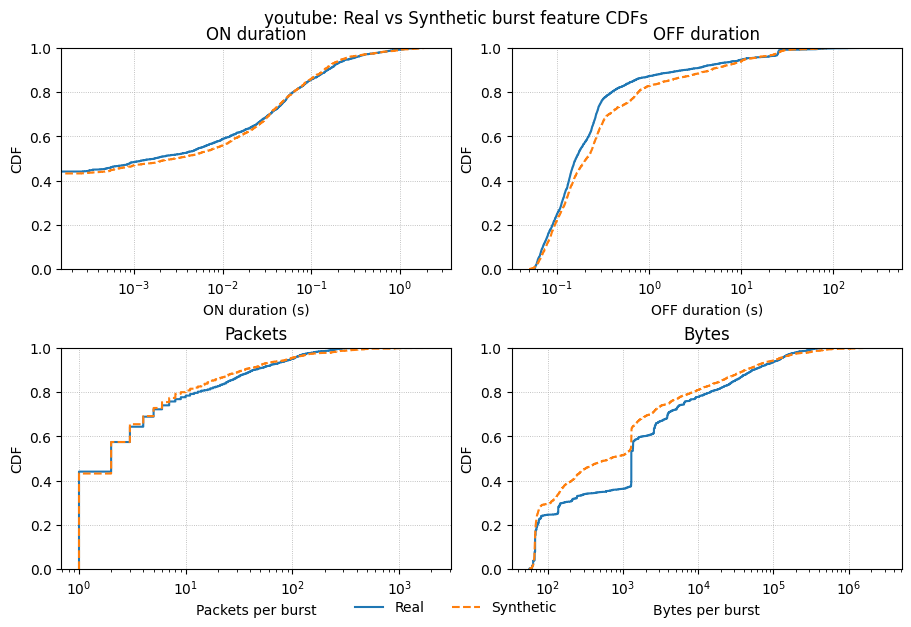

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/youtube_downlink_cdf_grid_test.pdf
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/youtube_downlink_cdf_grid_test.png


In [78]:
plot_app_cdf_grid(
    app_name=str(APP),
    real_df=real_test,  
    synth_df=synth_test,
    stem=f"{APP}_{DIRECTION}_cdf_grid_test"
)

# 11. computational time

In [79]:
import time
import os
import pickle
import tempfile
import inspect
import numpy as np
import pandas as pd

def bench(fn, n_rep=5, warmup=1):
    for _ in range(warmup):
        fn()
    times = []
    for _ in range(n_rep):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    times = np.asarray(times, dtype=float)
    return {
        "mean_s": float(times.mean()),
        "std_s": float(times.std(ddof=1)) if times.size > 1 else 0.0,
        "min_s": float(times.min()),
        "max_s": float(times.max()),
    }

def sizeof_bytes(obj) -> int:
    with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
        path = f.name
    sz = os.path.getsize(path)
    os.remove(path)
    return int(sz)

def run_generator_benchmarks(
    markov_model: dict,
    cluster_models: dict,
    T: int = 200_000,
    rng_seed: int = 123,
    n_rep_seq: int = 5,
    n_rep_emission: int = 3,
    n_rep_end2end: int = 5,
):
    required = ["sample_global_bursts_markov", "sample_cluster_sequence_markov", "sample_burst_from_cluster"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(f"Missing required functions in scope: {missing}")

    clusters = np.asarray(markov_model["clusters"])
    pi = np.asarray(markov_model["pi"], dtype=float)

    def job_seq():
        _ = sample_cluster_sequence_markov(T, markov_model, rng=rng_seed)

    def job_emission_fixed():
        rng = np.random.default_rng(rng_seed)
        for _ in range(T):
            _ = sample_burst_from_cluster(cluster_id=int(clusters[0]), rng=rng, need_valid_off=False)

    def job_emission_mix():
        rng = np.random.default_rng(rng_seed)
        idx = rng.choice(len(clusters), size=T, p=pi)
        for k in idx:
            _ = sample_burst_from_cluster(cluster_id=int(clusters[int(k)]), rng=rng, need_valid_off=True)

    def job_end2end():
        _ = sample_global_bursts_markov(T, markov_model, rng=rng_seed)

    seq_stats = bench(job_seq, n_rep=n_rep_seq, warmup=1)
    emi_fix_stats = bench(job_emission_fixed, n_rep=n_rep_emission, warmup=1)
    emi_mix_stats = bench(job_emission_mix, n_rep=n_rep_emission, warmup=1)
    e2e_stats = bench(job_end2end, n_rep=n_rep_end2end, warmup=1)

    seq_thr = T / seq_stats["mean_s"]
    emi_fix_thr = T / emi_fix_stats["mean_s"]
    emi_mix_thr = T / emi_mix_stats["mean_s"]
    e2e_thr = T / e2e_stats["mean_s"]

    markov_kb = sizeof_bytes(markov_model) / 1024
    clusters_kb = sizeof_bytes(cluster_models) / 1024
    total_kb = markov_kb + clusters_kb

    core_mean = seq_stats["mean_s"] + emi_mix_stats["mean_s"]
    overhead_s = e2e_stats["mean_s"] - core_mean
    overhead_frac = overhead_s / e2e_stats["mean_s"]

    rows = [
        {"component": "Markov sequence sampling", "mean_s": seq_stats["mean_s"], "std_s": seq_stats["std_s"], "throughput_per_s": seq_thr},
        {"component": "Emission (fixed state)",   "mean_s": emi_fix_stats["mean_s"], "std_s": emi_fix_stats["std_s"], "throughput_per_s": emi_fix_thr},
        {"component": "Emission (mixture by pi)", "mean_s": emi_mix_stats["mean_s"], "std_s": emi_mix_stats["std_s"], "throughput_per_s": emi_mix_thr},
        {"component": "End-to-end generator",     "mean_s": e2e_stats["mean_s"], "std_s": e2e_stats["std_s"], "throughput_per_s": e2e_thr},
    ]
    df = pd.DataFrame(rows)

    meta = {
        "T": int(T),
        "rng_seed": int(rng_seed),
        "model_size_kb": {
            "markov_model": float(markov_kb),
            "cluster_models": float(clusters_kb),
            "total": float(total_kb),
        },
        "end2end_overhead": {
            "core_mean_s": float(core_mean),
            "overhead_s": float(overhead_s),
            "overhead_fraction": float(overhead_frac),
        },
        "signature_sample_global_bursts_markov": str(inspect.signature(sample_global_bursts_markov)),
    }

    return df, meta

bench_df, bench_meta = run_generator_benchmarks(
    markov_model=markov_model,
    cluster_models=cluster_models,
    T=200_000,
    rng_seed=123,
)

try:
    from IPython.display import display
    display(bench_df)
except Exception:
    print(bench_df)

print("\nModel size (KB):", bench_meta["model_size_kb"])
print("End-to-end overhead:", bench_meta["end2end_overhead"])
print("sample_global_bursts_markov signature:", bench_meta["signature_sample_global_bursts_markov"])


,component,mean_s,std_s,throughput_per_s
0,Markov sequence sampling,0.959973,0.009080,208339.216399
1,Emission (fixed state),11.528226,0.086504,17348.723414
2,Emission (mixture by pi),8.973717,0.130746,22287.309488
3,End-to-end generator,14.842857,0.508699,13474.494722



Model size (KB): {'markov_model': 1.7763671875, 'cluster_models': 186.7197265625, 'total': 188.49609375}
End-to-end overhead: {'core_mean_s': 9.933689530933332, 'overhead_s': 4.9091675942666715, 'overhead_fraction': 0.3307427642035274}
sample_global_bursts_markov signature: (n_total: 'int', model: 'dict', rng: 'int | None' = 123) -> 'pd.DataFrame'


In [80]:
bench_df.to_csv(OUT("paper", "tables", f"bench_{APP}_{DIRECTION}.csv"), index=False)
save_json(OUT("bench_meta.json"), bench_meta)
print("Saved:", OUT("paper", "tables", f"bench_{APP}_{DIRECTION}.csv"))
print("Saved:", OUT("bench_meta.json"))


Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/tables/bench_youtube_downlink.csv
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/bench_meta.json


# 12. Transition matrix real vs synth 

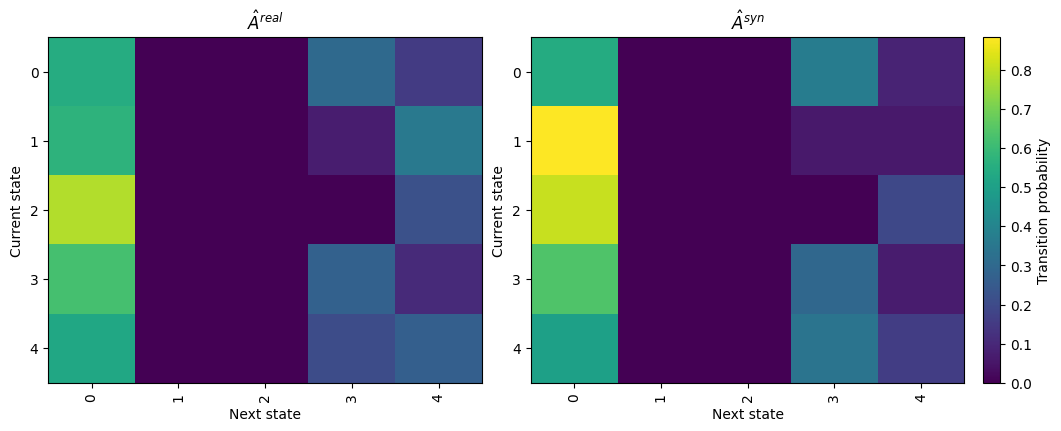

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_transition_real_vs_syn_youtube_downlink.pdf
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_transition_real_vs_syn_youtube_downlink.png


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# --- pick which real split to use for A_hat_real ---
if "core_test" in globals():
    REAL_DF = core_test
else:
    raise NameError("Could not find core_train/core_val/core_test in globals().")

if "markov_model" not in globals():
    raise NameError("markov_model not found. Fit it first (compute_cluster_markov(...)).")

# required columns 
FLOW_COL    = "flow_uid"
TIME_COL    = "t_start_s"
CLUSTER_COL = "cluster_hdb_all"

for c in [FLOW_COL, TIME_COL, CLUSTER_COL]:
    if c not in REAL_DF.columns:
        raise KeyError(f"REAL_DF missing required column '{c}'")

# output dir 
if "FIG_DIR" not in globals():
    FIG_DIR = Path("paper") / "figs"
    FIG_DIR.mkdir(parents=True, exist_ok=True)

APP_ = globals().get("APP", "app")
DIR_ = globals().get("DIRECTION", "direction")

# state set aligned to the Markov model
clusters = np.asarray(markov_model["clusters"])
K = len(clusters)
idx = {c: i for i, c in enumerate(clusters)}

def _extract_real_sequences(df: pd.DataFrame) -> list[np.ndarray]:
    """List of per-flow cluster sequences from real data (sorted by time)."""
    seqs = []
    df2 = df[[FLOW_COL, TIME_COL, CLUSTER_COL]].dropna().copy()
    df2 = df2[df2[CLUSTER_COL].isin(clusters)]
    df2 = df2.sort_values([FLOW_COL, TIME_COL])

    for _, g in df2.groupby(FLOW_COL, sort=False):
        seq = g[CLUSTER_COL].to_numpy()
        if len(seq) >= 2:
            seqs.append(seq)
    return seqs

def _sample_synth_sequences_from_model(n_flows: int, rng_seed: int = 123) -> list[np.ndarray]:
    """
    Sample per-flow sequences from markov_model:
      - length sampled from model["flow_lengths"]
      - chain reset per flow using pi
    """
    rng = np.random.default_rng(rng_seed)

    P  = np.asarray(markov_model["P"], dtype=float)
    pi = np.asarray(markov_model["pi"], dtype=float)

    flow_lengths = np.asarray(markov_model.get("flow_lengths", []), dtype=int)
    if flow_lengths.size == 0:
        raise RuntimeError("markov_model['flow_lengths'] is empty/missing. Cannot sample per-flow sequences.")

    # normalize safely
    pi = pi / max(pi.sum(), 1.0)
    row_sums = P.sum(axis=1, keepdims=True)
    P = np.divide(P, np.maximum(row_sums, 1e-12))

    seqs = []
    for _ in range(int(n_flows)):
        L = int(rng.choice(flow_lengths))
        if L < 2:
            continue

        s_idx = np.empty(L, dtype=int)
        s_idx[0] = rng.choice(K, p=pi)
        for t in range(1, L):
            s_idx[t] = rng.choice(K, p=P[s_idx[t-1]])

        seqs.append(clusters[s_idx])
    return seqs

def _estimate_A_hat(seqs: list[np.ndarray], alpha: float = 1e-3) -> np.ndarray:
    """
    Estimate row-stochastic transition matrix from sequences.
    alpha: Laplace smoothing on counts 
    """
    counts = np.zeros((K, K), dtype=float)
    for seq in seqs:
        for a, b in zip(seq[:-1], seq[1:]):
            ia = idx.get(a, None)
            ib = idx.get(b, None)
            if ia is None or ib is None:
                continue
            counts[ia, ib] += 1.0

    if alpha > 0:
        counts += float(alpha)

    row = counts.sum(axis=1, keepdims=True)
    A = np.divide(counts, np.maximum(row, 1e-12))
    return A

# build A_hat_real and A_hat_syn
real_seqs = _extract_real_sequences(REAL_DF)
if len(real_seqs) == 0:
    raise RuntimeError("No real sequences found (need >=2 bursts per flow and valid clusters).")

# sample about the same number of flows as real for fair finite-sample comparison
syn_seqs = _sample_synth_sequences_from_model(n_flows=len(real_seqs), rng_seed=2026)

A_hat_real = _estimate_A_hat(real_seqs, alpha=0.0)
A_hat_syn  = _estimate_A_hat(syn_seqs,  alpha=0.0)

# plot: two heatmaps, shared scale
vmin = 0.0
vmax = float(np.max([A_hat_real.max(), A_hat_syn.max()]))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)

im0 = axes[0].imshow(A_hat_real, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest")
axes[0].set_title(r"$\hat{A}^{real}$")
axes[0].set_xlabel("Next state")
axes[0].set_ylabel("Current state")

im1 = axes[1].imshow(A_hat_syn, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest")
axes[1].set_title(r"$\hat{A}^{syn}$")
axes[1].set_xlabel("Next state")
axes[1].set_ylabel("Current state")


if K <= 20:
    tick_pos = np.arange(K)
    tick_lab = [str(c) for c in clusters]
    for ax in axes:
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_lab, rotation=90)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_lab)
else:
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

cbar = fig.colorbar(im1, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("Transition probability")

out_base = FIG_DIR / f"fig_transition_real_vs_syn_{APP_}_{DIR_}"
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(out_base.with_suffix(".png"), dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", out_base.with_suffix(".pdf"))
print("Saved:", out_base.with_suffix(".png"))

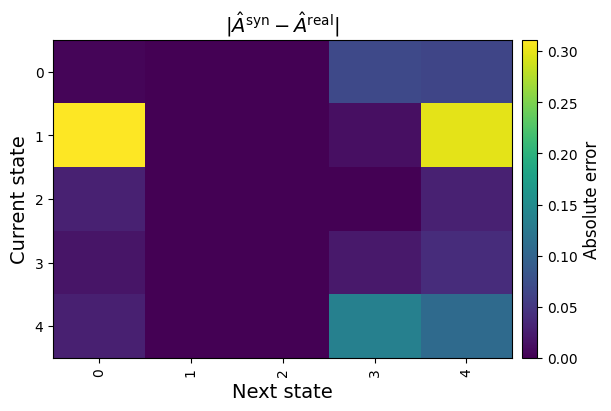

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_transition_error_youtube_downlink_absolute.png
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_transition_error_youtube_downlink_absolute.pdf


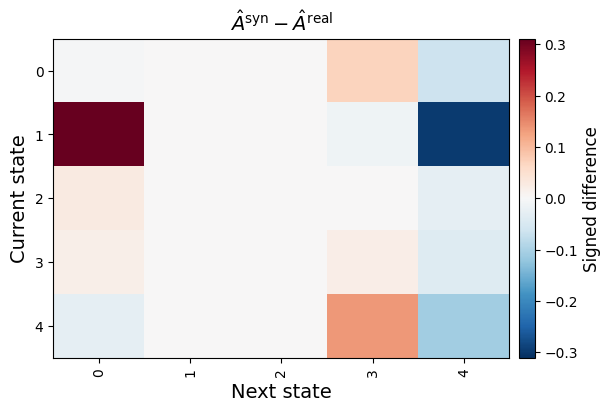

Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_transition_error_youtube_downlink_signed.png
Saved: /Users/ghinwaismail/Desktop/trafficgen-paper/artifacts/youtube/downlink/run_20260126_161755/paper/figs/fig_transition_error_youtube_downlink_signed.pdf


In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

def plot_transition_error_maps(
    A_hat_real: np.ndarray,
    A_hat_syn: np.ndarray,
    clusters: np.ndarray,
    out_base: str | Path,
):
    A_hat_real = np.asarray(A_hat_real, dtype=float)
    A_hat_syn  = np.asarray(A_hat_syn, dtype=float)
    
    if A_hat_real.shape != A_hat_syn.shape:
        raise ValueError(f"Shape mismatch: real={A_hat_real.shape}, syn={A_hat_syn.shape}")
    if A_hat_real.ndim != 2 or A_hat_real.shape[0] != A_hat_real.shape[1]:
        raise ValueError("A_hat matrices must be square (K x K).")
    
    K = A_hat_real.shape[0]
    clusters = np.asarray(clusters)
    
    D = A_hat_syn - A_hat_real
    absD = np.abs(D)
    
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    
    # ----- Figure (a): Absolute error -----
    fig_a, ax_a = plt.subplots(figsize=(6, 4), constrained_layout=True)
    
    vmax_abs = float(np.nanmax(absD)) if np.isfinite(absD).any() else 1.0
    im_a = ax_a.imshow(absD, aspect="auto", interpolation="nearest", vmin=0.0, vmax=vmax_abs)
    ax_a.set_title(r"$|\hat{A}^{\mathrm{syn}} - \hat{A}^{\mathrm{real}}|$", fontsize=14)
    ax_a.set_xlabel("Next state", fontsize=14)
    ax_a.set_ylabel("Current state",fontsize=14)
    cb_a = fig_a.colorbar(im_a, ax=ax_a, fraction=0.046, pad=0.02)
    cb_a.set_label("Absolute error", fontsize=12)
    
    if K <= 20:
        ticks = np.arange(K)
        labels = [str(int(c)) for c in clusters]
        ax_a.set_xticks(ticks)
        ax_a.set_yticks(ticks)
        ax_a.set_xticklabels(labels, rotation=90)
        ax_a.set_yticklabels(labels)
    else:
        ax_a.set_xticks([])
        ax_a.set_yticks([])
    
    # Save figure (a)
    out_a = out_base.parent / f"{out_base.stem}_absolute"
    fig_a.savefig(out_a.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig_a.savefig(out_a.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    print("Saved:", out_a.with_suffix(".png"))
    print("Saved:", out_a.with_suffix(".pdf"))
    
    # ----- Figure (b): Signed difference -----
    fig_b, ax_b = plt.subplots(figsize=(6, 4), constrained_layout=True)
    
    maxabs = float(np.nanmax(np.abs(D))) if np.isfinite(D).any() else 1.0
    norm = TwoSlopeNorm(vmin=-maxabs, vcenter=0.0, vmax=maxabs)
    im_b = ax_b.imshow(D, aspect="auto", interpolation="nearest", norm=norm, cmap="RdBu_r")
    ax_b.set_title(r"$\hat{A}^{\mathrm{syn}} - \hat{A}^{\mathrm{real}}$", fontsize=14)
    ax_b.set_xlabel("Next state", fontsize=14)
    ax_b.set_ylabel("Current state", fontsize=14)
    cb_b = fig_b.colorbar(im_b, ax=ax_b, fraction=0.046, pad=0.02)
    cb_b.set_label("Signed difference", fontsize=12)
    
    if K <= 20:
        ticks = np.arange(K)
        labels = [str(int(c)) for c in clusters]
        ax_b.set_xticks(ticks)
        ax_b.set_yticks(ticks)
        ax_b.set_xticklabels(labels, rotation=90)
        ax_b.set_yticklabels(labels)
    else:
        ax_b.set_xticks([])
        ax_b.set_yticks([])
    
    # Save figure (b)
    out_b = out_base.parent / f"{out_base.stem}_signed"
    fig_b.savefig(out_b.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig_b.savefig(out_b.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    print("Saved:", out_b.with_suffix(".png"))
    print("Saved:", out_b.with_suffix(".pdf"))


# Run the function
out_base = (globals().get("FIG_DIR", Path("paper") / "figs")) / f"fig_transition_error_{APP_}_{DIR_}"
plot_transition_error_maps(A_hat_real, A_hat_syn, clusters, out_base)